# 0 - Helpers

In [ ]:
from notebooks_function import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
import country_converter as coco
from collections import Counter
import os
import cartopy.crs as ccrs


def plot_bar(df, colors, ylabel=None, title=None, figsize=(12, 6), vert_lines=True):
    # Create figure and axis with adjustable size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Clean 'virtual ' prefix from index names
    df = clean_virtual_names(df.copy())
    
    # Remove column names from MultiIndex if present
    df_plot = df.copy()
    if isinstance(df_plot.columns, pd.MultiIndex):
        df_plot.columns = df_plot.columns.set_names([None, None])

    # Create stacked bar plot on the provided axis
    df_plot.T.plot(kind="bar", stacked=True, legend=True, color=colors, ax=ax)

    # Reverse legend order
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1],
              loc='upper left', bbox_to_anchor=(1, 1),
              title='Carrier')

    # Add total values above each bar
    bar_totals = df.T.sum(axis=1)  # totals per bar
    bar_height = df.clip(lower=0).T.sum(axis=1)
    
    for i, total in enumerate(bar_totals):
        ax.text(
            i,                              # x position
            bar_height.iloc[i],             # y position
            "{:.0f}".format(total),         # label
            ha='center', va='bottom',
            fontsize=9
        )

    # Check if we have MultiIndex columns (year, scenario structure)
    if isinstance(df.columns, pd.MultiIndex):
        # Get years and scenarios
        years = df.columns.get_level_values('year').unique()
        scenarios = df.columns.get_level_values('scenario').unique()
        
        # Set x-axis labels to show only scenarios
        ax.set_xticklabels([sc for _, sc in df.columns], rotation=45, ha='right')
        
        # Add year labels as a secondary x-axis
        # Calculate position for each year group
        year_positions = []
        year_labels = []
        for year in years:
            year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
            if year_cols:
                year_positions.append(np.mean(year_cols))
                year_labels.append(str(year))
        
        # Add vertical lines between years
        if vert_lines and len(years) > 1:
            for year in years[:-1]:
                year_cols = [i for i, (y, s) in enumerate(df.columns) if y == year]
                if year_cols:
                    ax.axvline(max(year_cols) + 0.5, color='gray', linestyle='--', linewidth=1)
        
        # Add secondary x-axis for years
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks(year_positions)
        ax2.set_xticklabels(year_labels)
        ax2.tick_params(axis='x', which='both', length=0)  # Hide tick marks
        ax2.spines['top'].set_visible(False)
    else:
        # Fallback for non-MultiIndex columns (old behavior)
        ax.set_xticklabels(df.columns, rotation=45, ha='right')
        
        if vert_lines:
            group_bars = max(Counter([int(c[-4:]) for c in df.columns]).values())
            num_bars = df.T.shape[0]
            for i in range(0, num_bars, group_bars):
                ax.axvline(i - 0.5, color='gray', linestyle='--', linewidth=1)
    
    # Labels
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.grid(axis='y')

    return ax


from pypsa.plot.maps.static import add_legend_circles, add_legend_patches

def add_legends(df, ax, colors):
    
    # --- Carrier patches legend ---
    legend_colors = colors.values
    legend_labels = colors.index
    
    legend_kw = {
        "loc": "upper left",
        "bbox_to_anchor": (1.0, 1.0),
        "handletextpad": 0.2,
        "title": r"Carrier",
        "alignment": "center",
        "ncol": 1
    }
    
    add_legend_patches(
        ax,
        legend_colors,
        legend_labels,
        legend_kw=legend_kw
    )

    df_bus = df.groupby("bus").sum()
    df_bus = df_bus[df_bus > 0]
    
    for bus, size in df_bus.items():
        # Get coordinates
        lon = n.buses.at[bus, "x"]
        lat = n.buses.at[bus, "y"]
        
        # Transform coordinates into the plot projection
        x, y = ax.projection.transform_point(lon, lat, ccrs.PlateCarree())

        ax.text(
            x, y,
            f"{size:.1f}",
            ha="center", va="center",
            fontsize=8,
            color="black",
            zorder=5
        )


def load_projection(plotting_params):
    proj_kwargs = plotting_params.get("projection", dict(name="EqualEarth"))
    proj_func = getattr(ccrs, proj_kwargs.pop("name"))
    return proj_func(**proj_kwargs)


def plot_map(df, df_n, colors, unit=None, title=None, bus_size_factor=1e1,save=False, path=None):
    
    colors = colors.groupby("carrier").first()
    proj = load_projection({})

    for i in df_n.index:
        #print(f"-------------------------------------Analyzing {i}")
        n = df_n.loc[i]

        df_scenario = df[i]
        
        bus_size = df_scenario / bus_size_factor

        fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": proj})
        n.plot.map(ax=ax, bus_size=bus_size, bus_colors = colors, line_widths=0, link_widths=0, boundaries = [-11, 30, 34, 71])

        add_legends(df_scenario, ax, colors)

        if title is not None:
            fig_title = f"{title} {i}"
            ax.set_title(fig_title)

        if unit is not None:
            fig.text(
                0.32, 0.5,
                f"{unit}",
                rotation=90,
                va='center',
                ha='center',
            )
        if save:
            ax.figure.savefig(f"{path}/{fig_title}.png", dpi=300, bbox_inches="tight")

# 1 - Retrieve networks

In [2]:
years = [2025, 2030, 2035, 2040]
# Main
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]


# Sensitivities NOTE: change the folder directory for Sensitivites
# scenarios = ["baseline", # Main
#              "hourly-match-noadd-10-99",
#              "hourly-match-noadd-50-99",
#              "hourly-match-noadd-90-99",
#              "hourly-match-50-99", # Main
#              "hourly-match-no-clean-firm-50-99",
#              "hourly-match-no-LDES-50-99",
#             ]

# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n, year)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current:

# 2 - GO Market impacts - bar plot

### (b) Energy mix - GO Market

-------------------------------------Analyzing (2025, 'energy-match-50')
-------------------------------------Analyzing (2025, 'hourly-match-50-90')
-------------------------------------Analyzing (2025, 'hourly-match-50-90')
-------------------------------------Analyzing (2025, 'hourly-match-50-95')
-------------------------------------Analyzing (2025, 'hourly-match-50-95')
-------------------------------------Analyzing (2025, 'hourly-match-50-98')
-------------------------------------Analyzing (2025, 'hourly-match-50-98')
-------------------------------------Analyzing (2025, 'hourly-match-50-99')
-------------------------------------Analyzing (2025, 'hourly-match-50-99')
-------------------------------------Analyzing (2030, 'energy-match-50')
-------------------------------------Analyzing (2030, 'energy-match-50')
-------------------------------------Analyzing (2030, 'hourly-match-50-90')
-------------------------------------Analyzing (2030, 'hourly-match-50-90')
---------------------

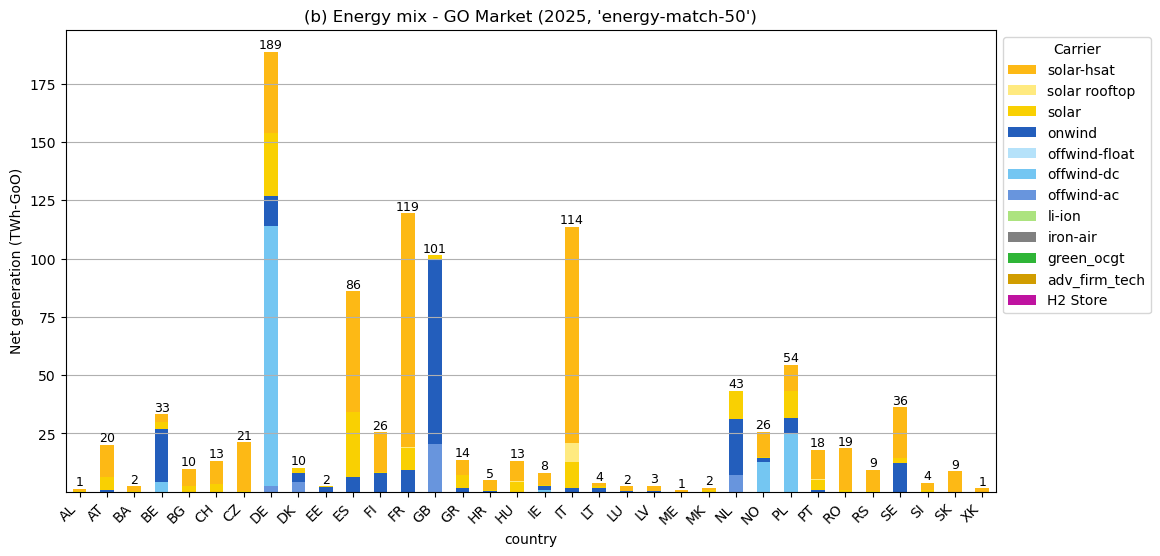

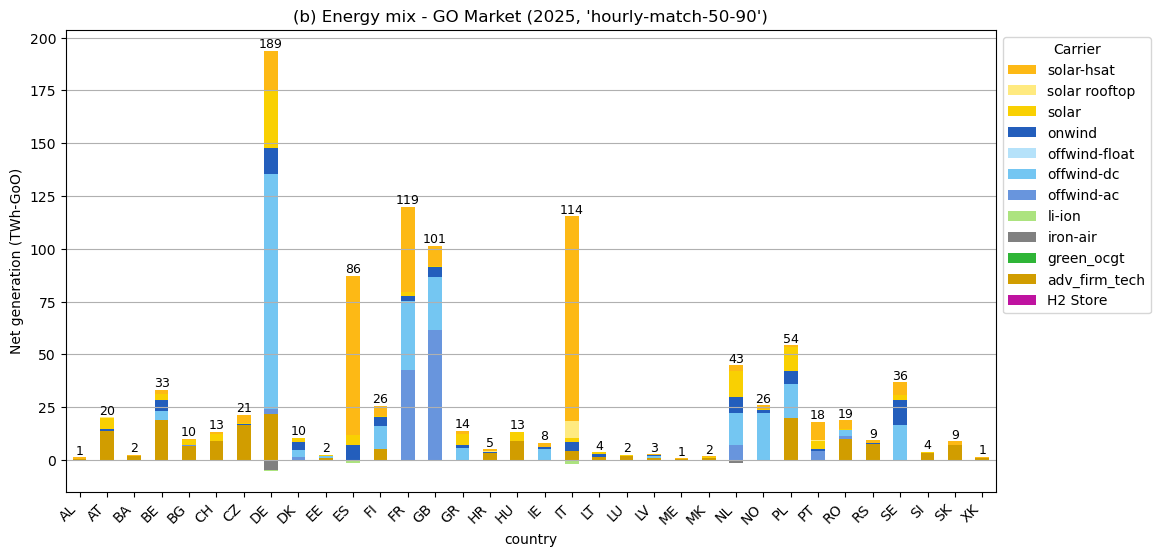

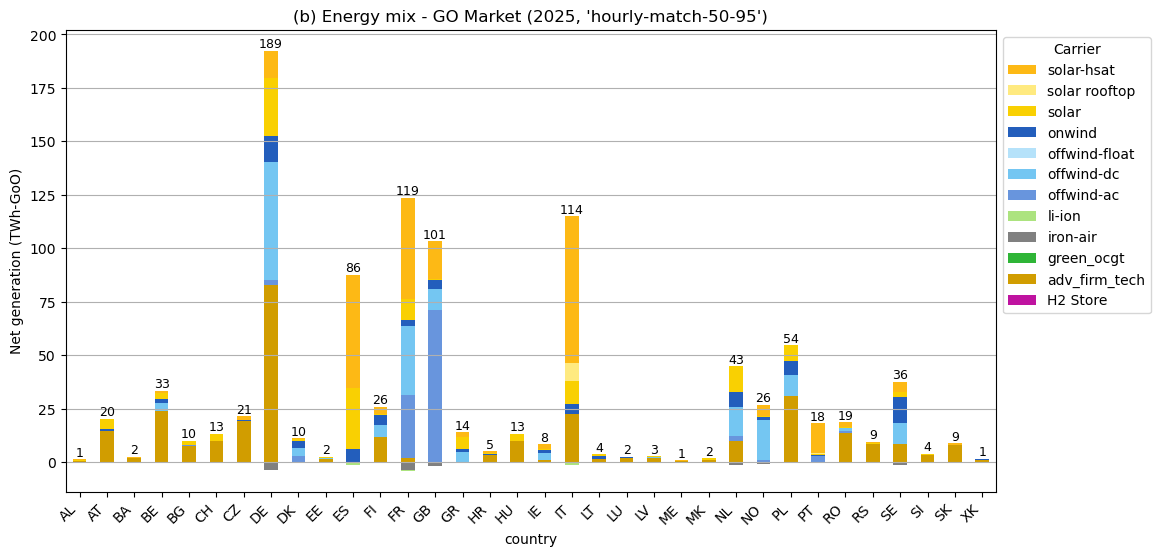

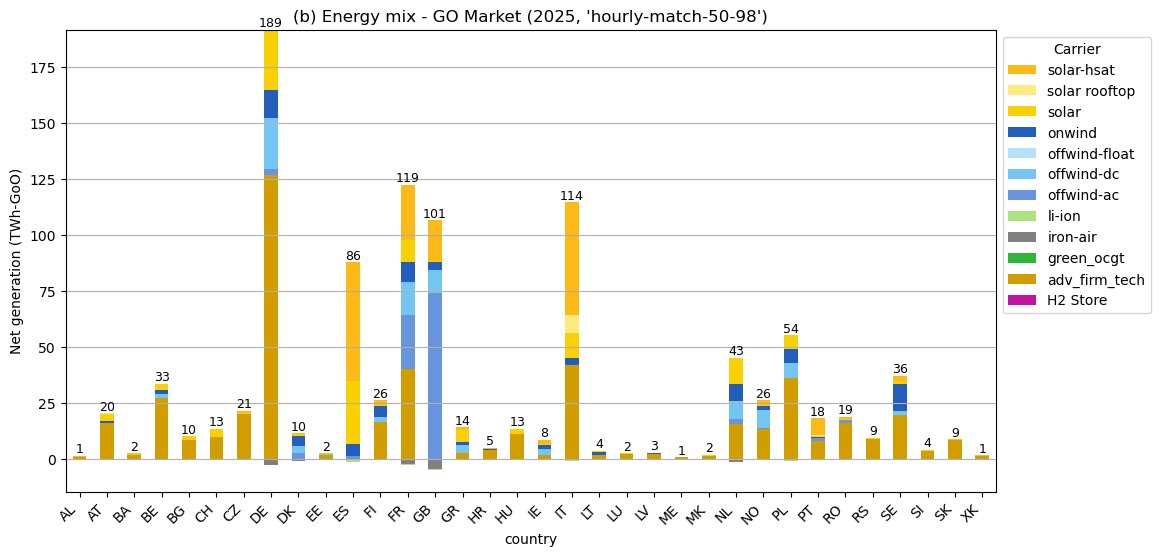

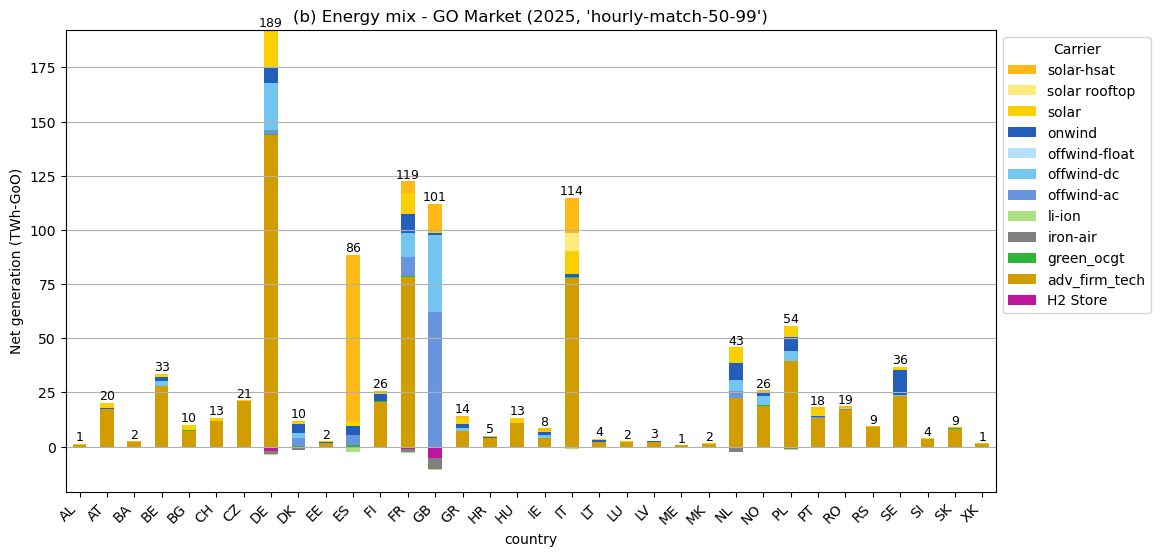

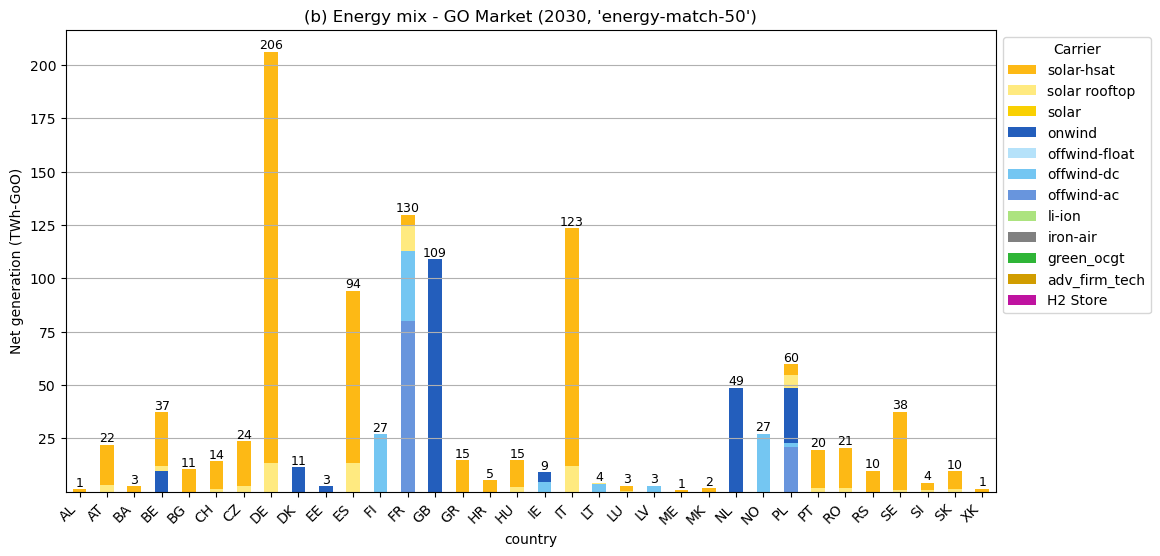

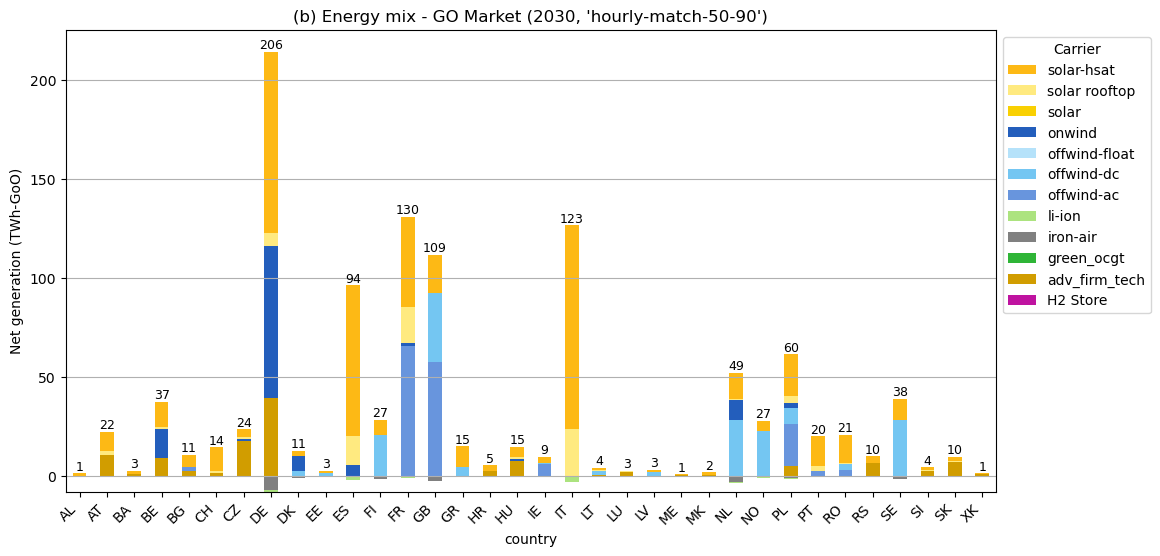

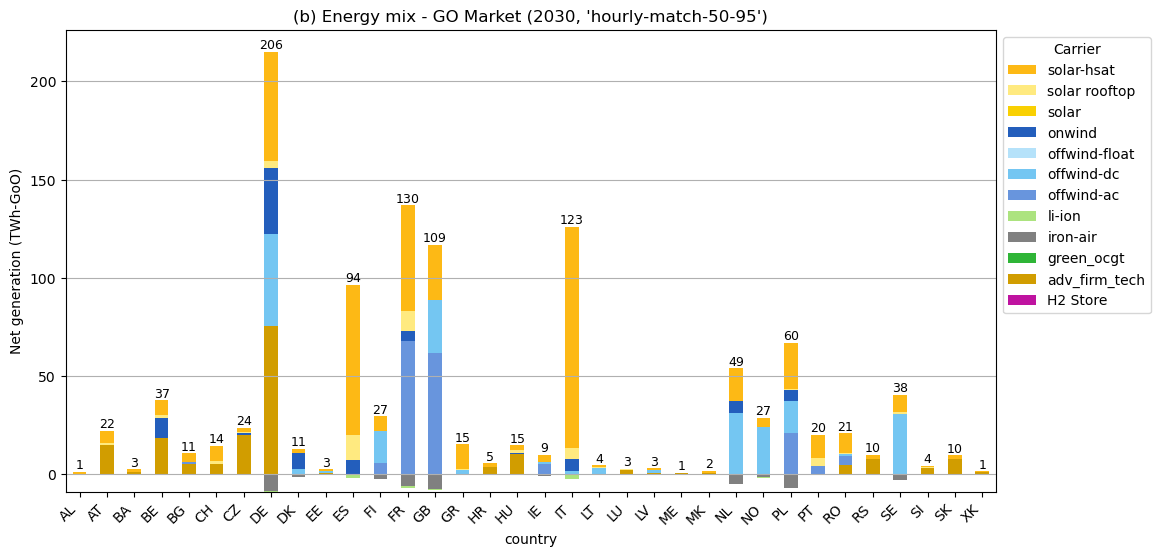

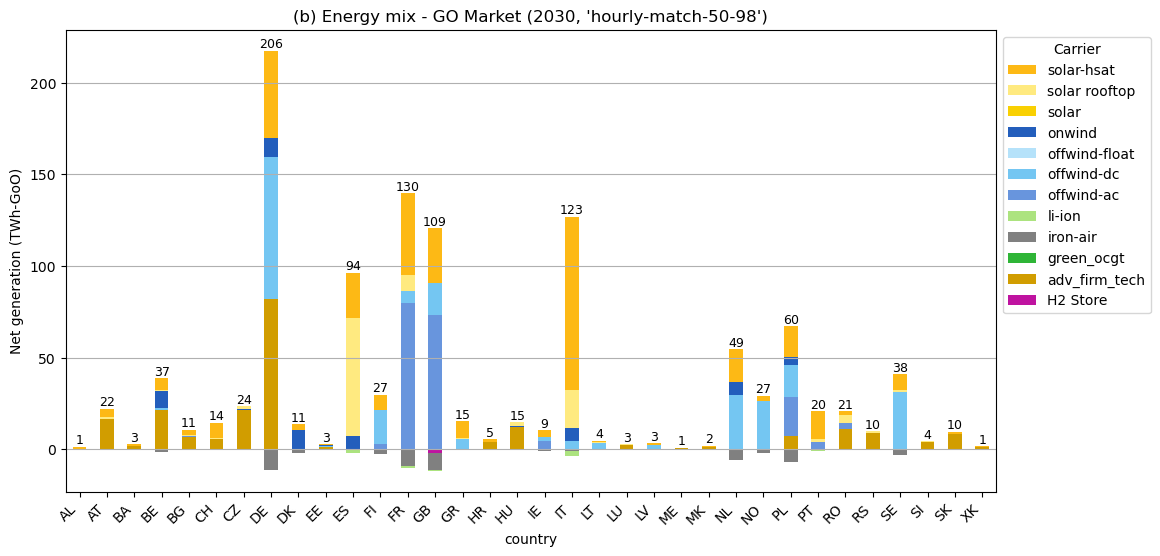

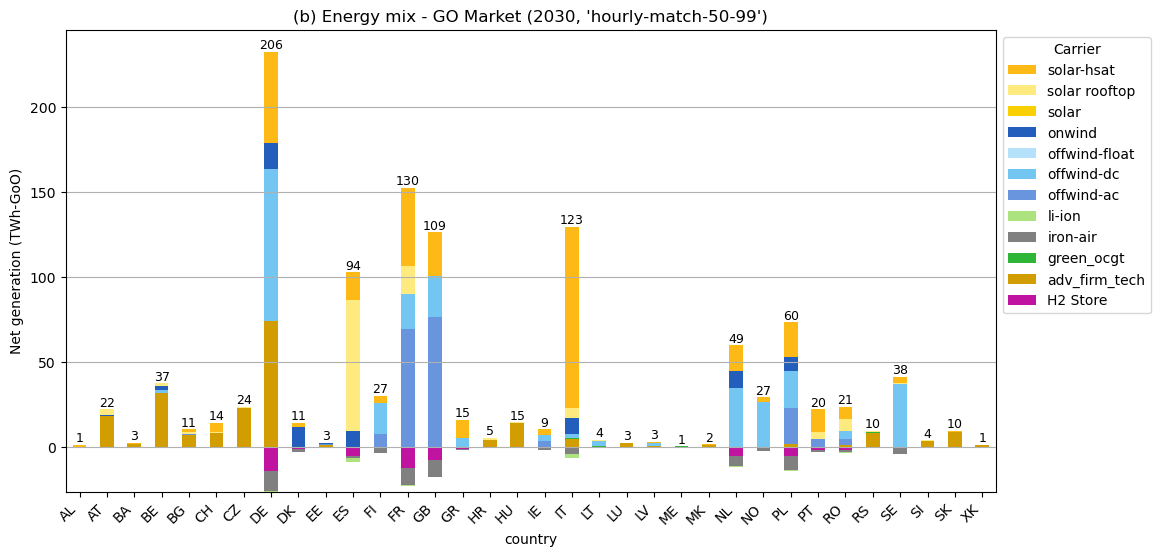

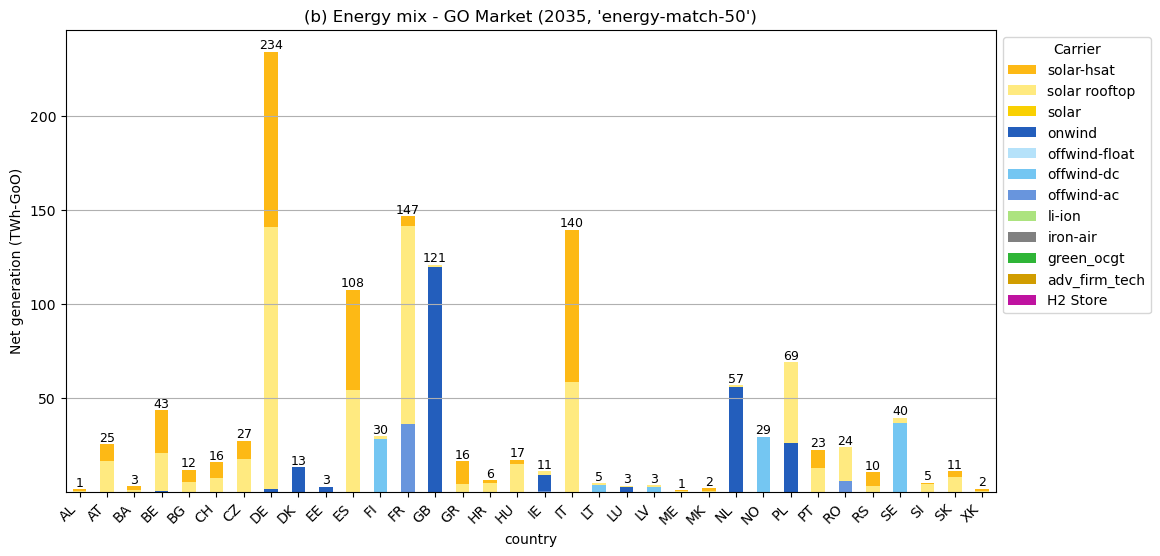

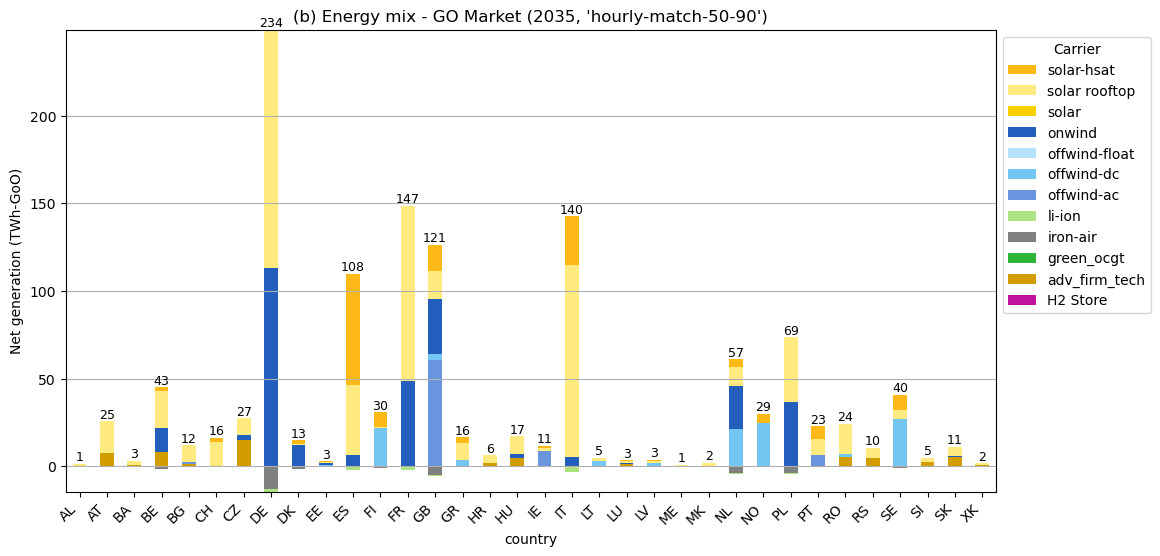

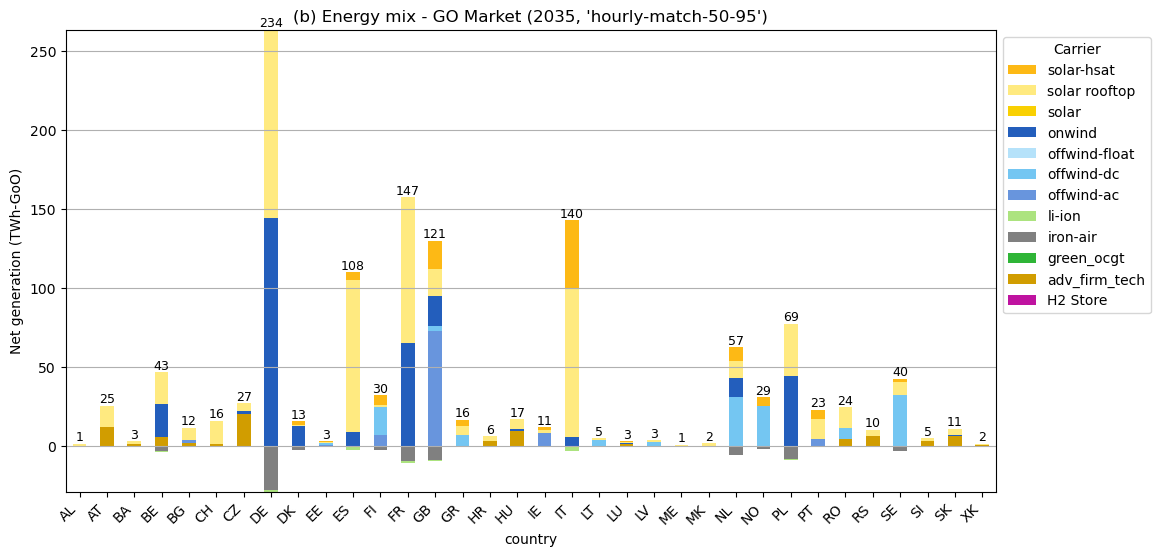

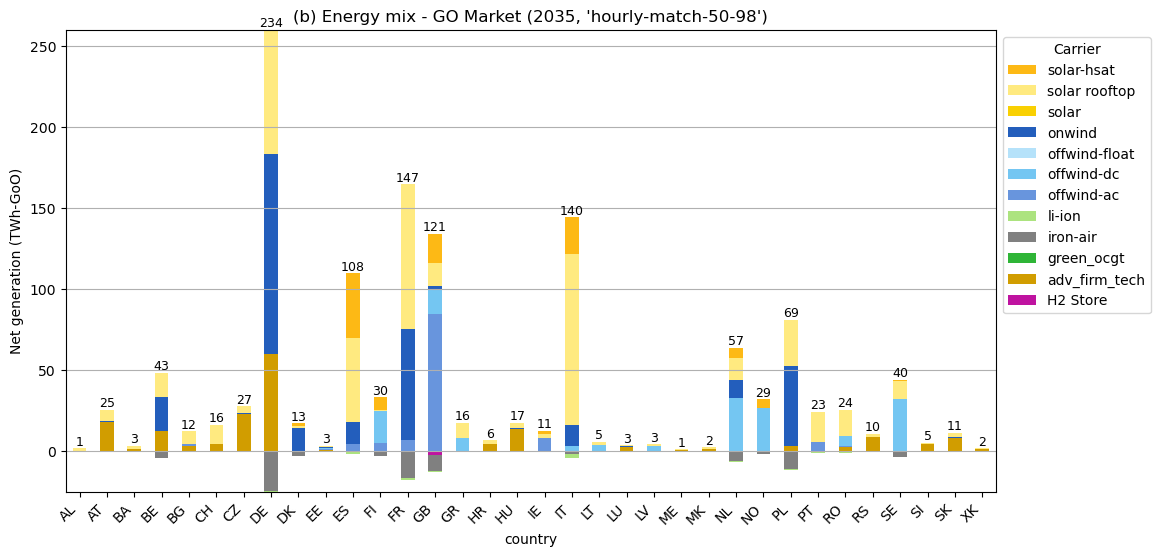

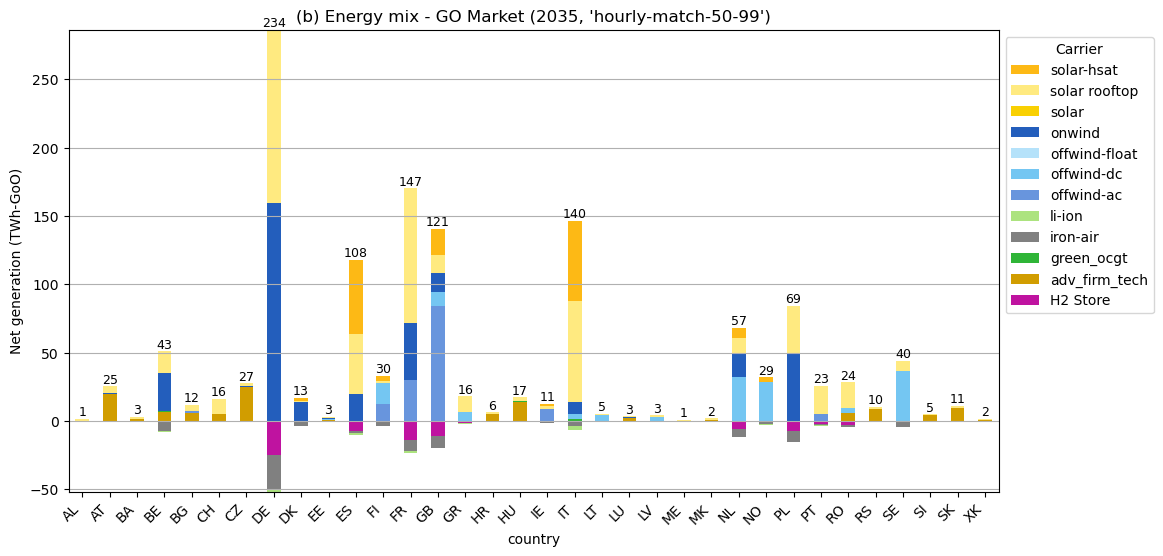

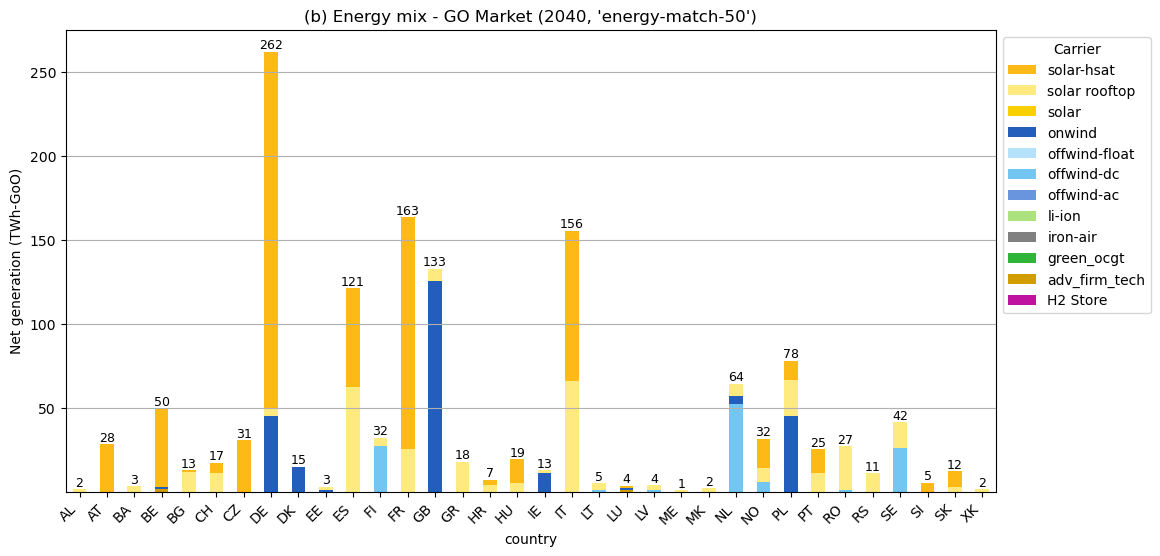

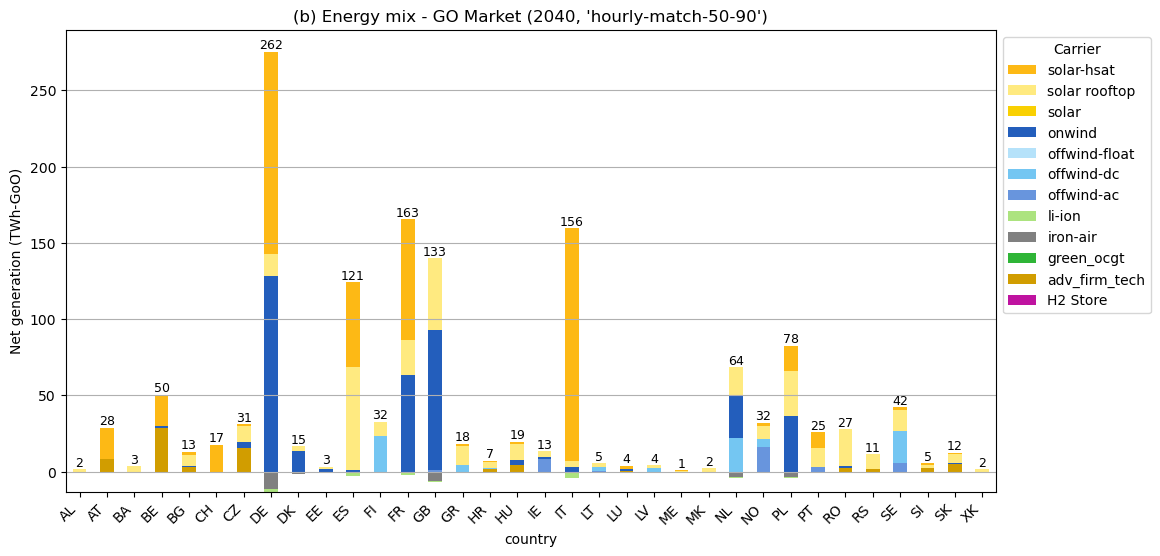

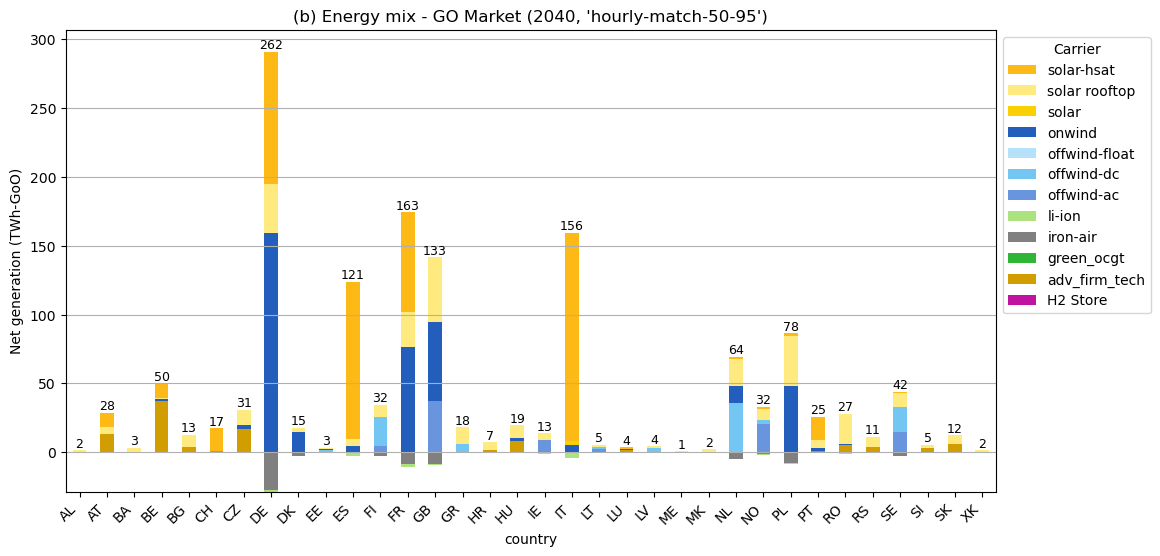

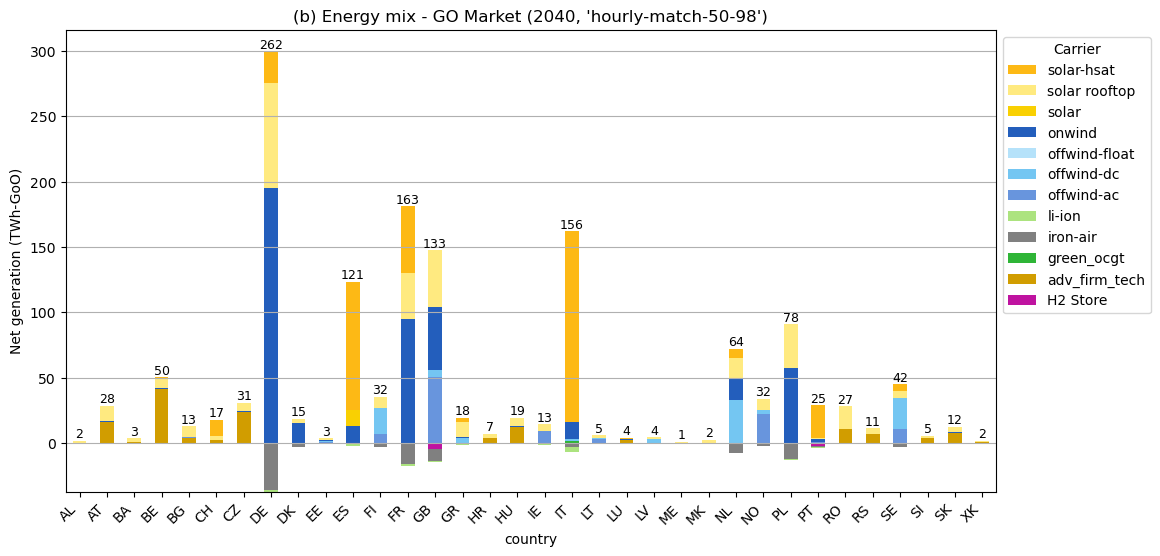

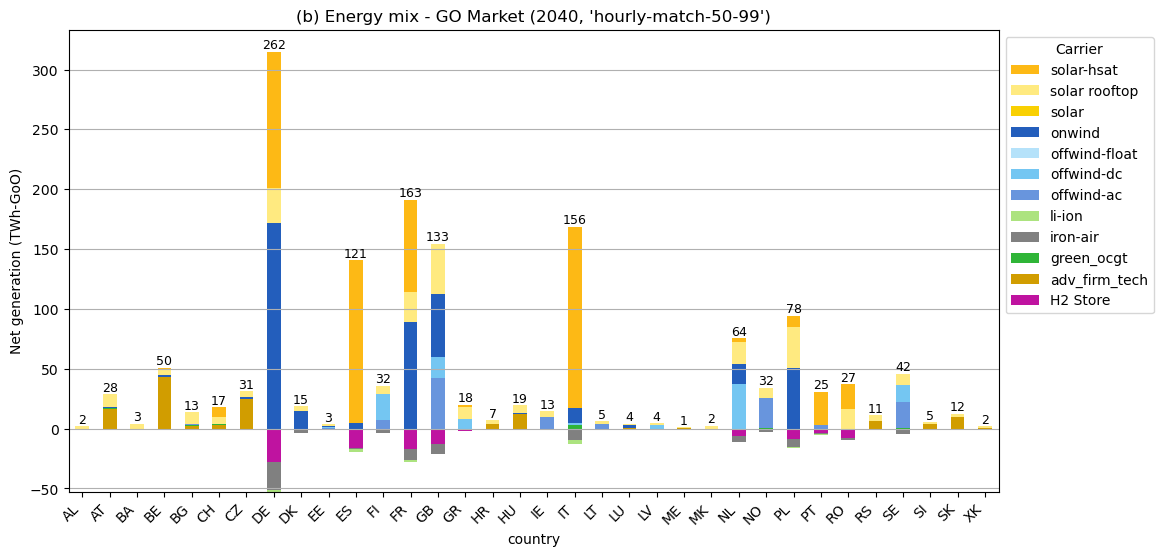

In [32]:
save_fig = True
df_GoO = df_networks[df_networks.index.get_level_values("scenario") != "baseline"]
df, _ = get_stats_all(df_GoO["GoO"], "energy_balance", groupby=["country","carrier"])
df = df[df.index.get_level_values("carrier") != "GoO"]

for i in df.columns:
    fig_path = f"figures/country_comparison/bar_plots"
    print(f"-------------------------------------Analyzing {i}")

    title_fig = f"(b) Energy mix - GO Market {i}"
    df_country = df[i]
    df_country = df_country.unstack("country").groupby("carrier").sum()
    df_country = df_country / 1e6

    colors = df_country.index.map(n.carriers.color)
    
    ax = plot_bar(
        df_country, 
        colors, 
        ylabel="Net generation (TWh-GoO)", 
        title=title_fig,
        vert_lines=False
    )
    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

### (i) Weighted average marginal price of GOs

-------------------------------------Analyzing (2025, 'baseline')
-------------------------------------Analyzing (2025, 'energy-match-50')
-------------------------------------Analyzing (2025, 'energy-match-50')
-------------------------------------Analyzing (2025, 'hourly-match-50-90')
-------------------------------------Analyzing (2025, 'hourly-match-50-90')
-------------------------------------Analyzing (2025, 'hourly-match-50-95')
-------------------------------------Analyzing (2025, 'hourly-match-50-95')
-------------------------------------Analyzing (2025, 'hourly-match-50-98')
-------------------------------------Analyzing (2025, 'hourly-match-50-98')
-------------------------------------Analyzing (2025, 'hourly-match-50-99')
-------------------------------------Analyzing (2025, 'hourly-match-50-99')
-------------------------------------Analyzing (2030, 'baseline')
-------------------------------------Analyzing (2030, 'baseline')
-------------------------------------Analyzing (

/tmp/ipykernel_20424/2108685961.py:251: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



-------------------------------------Analyzing (2040, 'hourly-match-50-95')
-------------------------------------Analyzing (2040, 'hourly-match-50-98')
-------------------------------------Analyzing (2040, 'hourly-match-50-98')
-------------------------------------Analyzing (2040, 'hourly-match-50-99')
-------------------------------------Analyzing (2040, 'hourly-match-50-99')


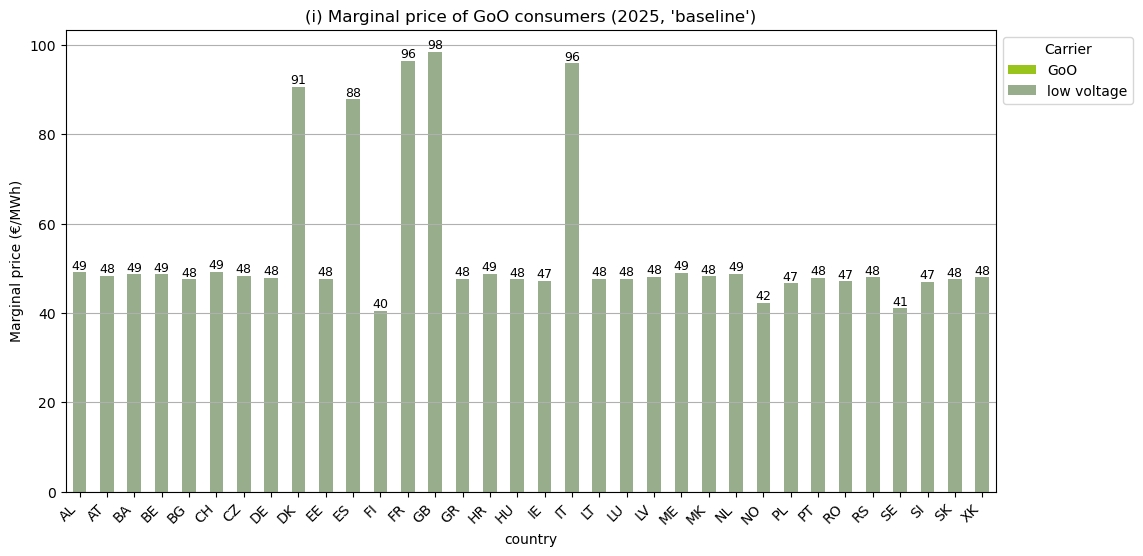

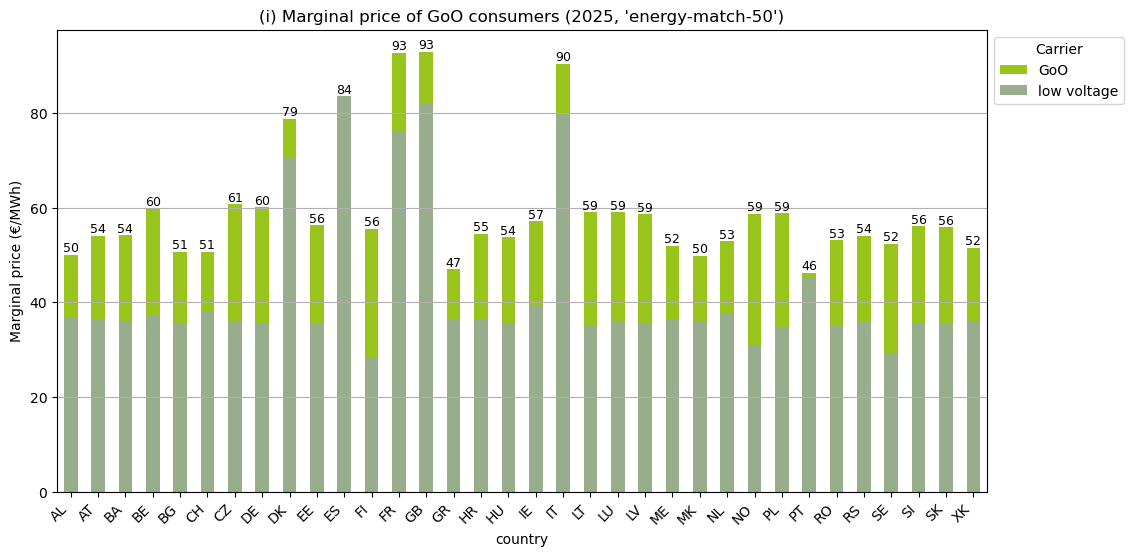

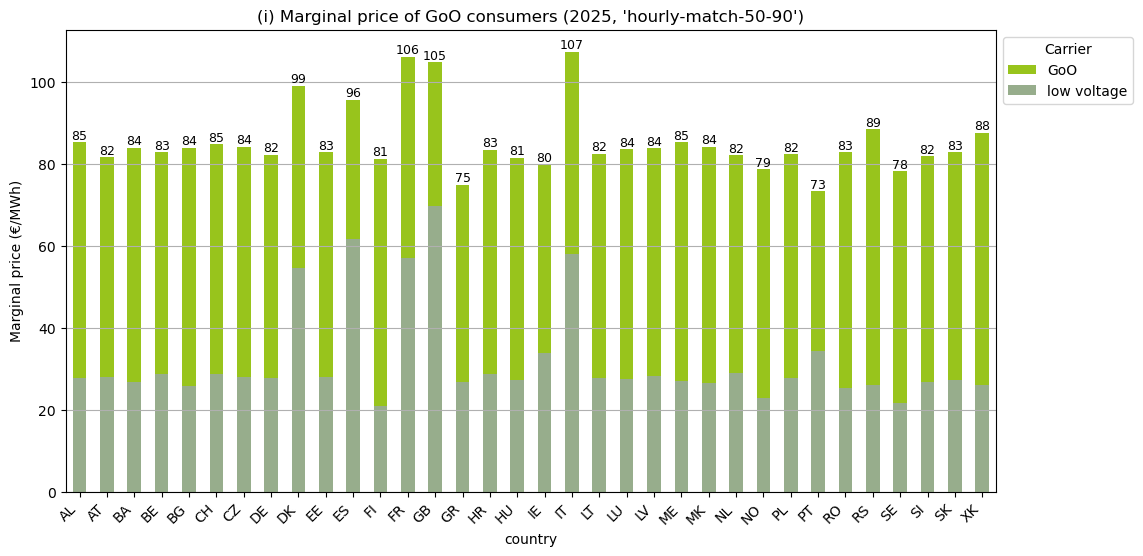

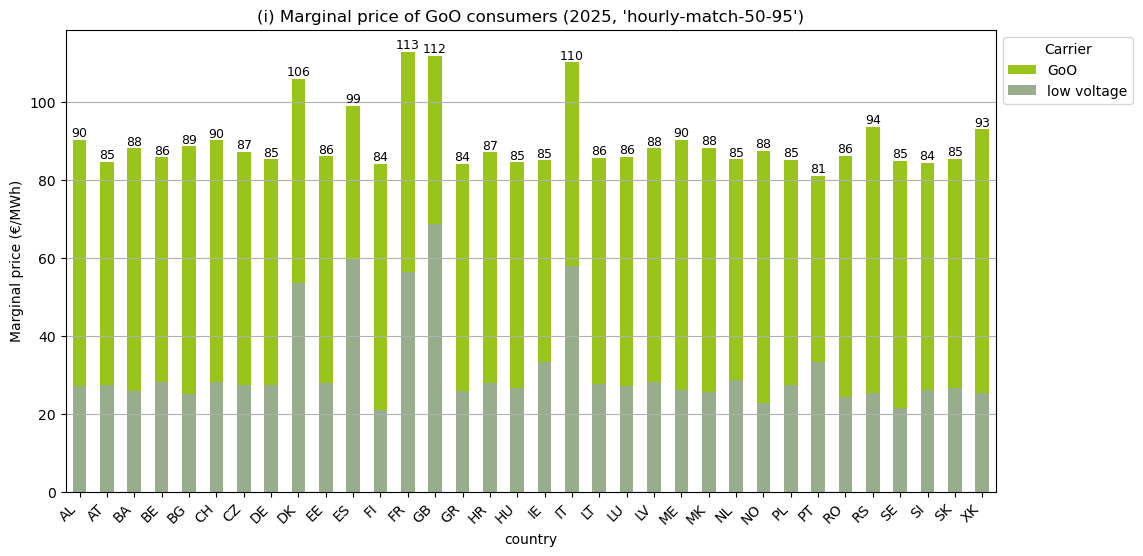

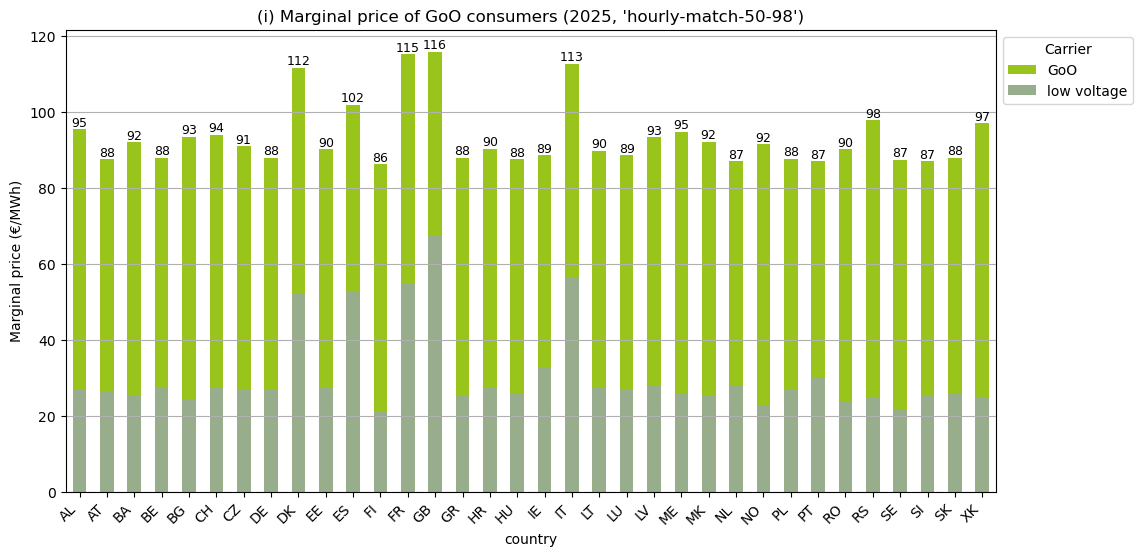

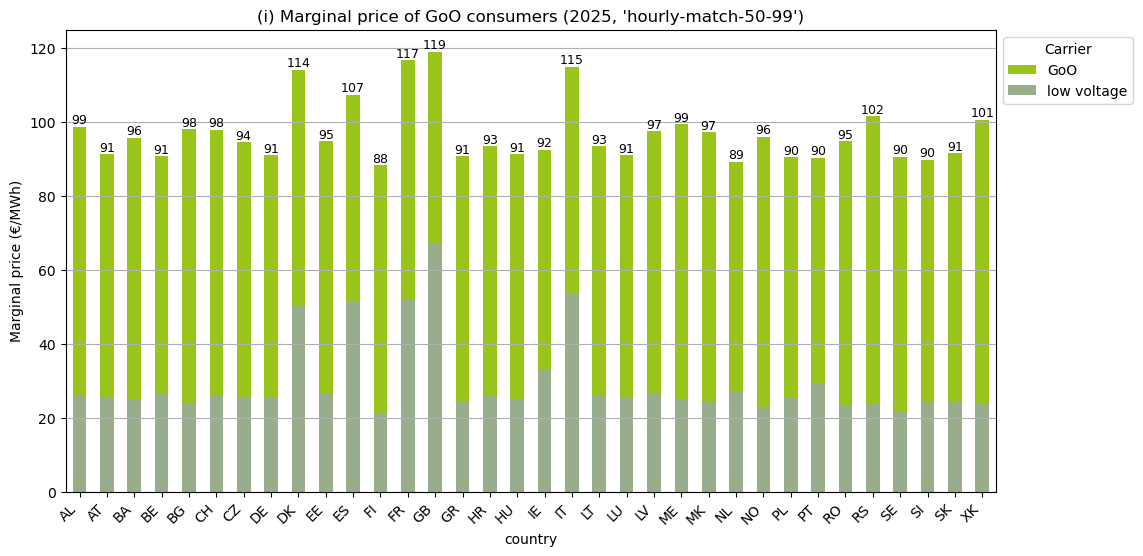

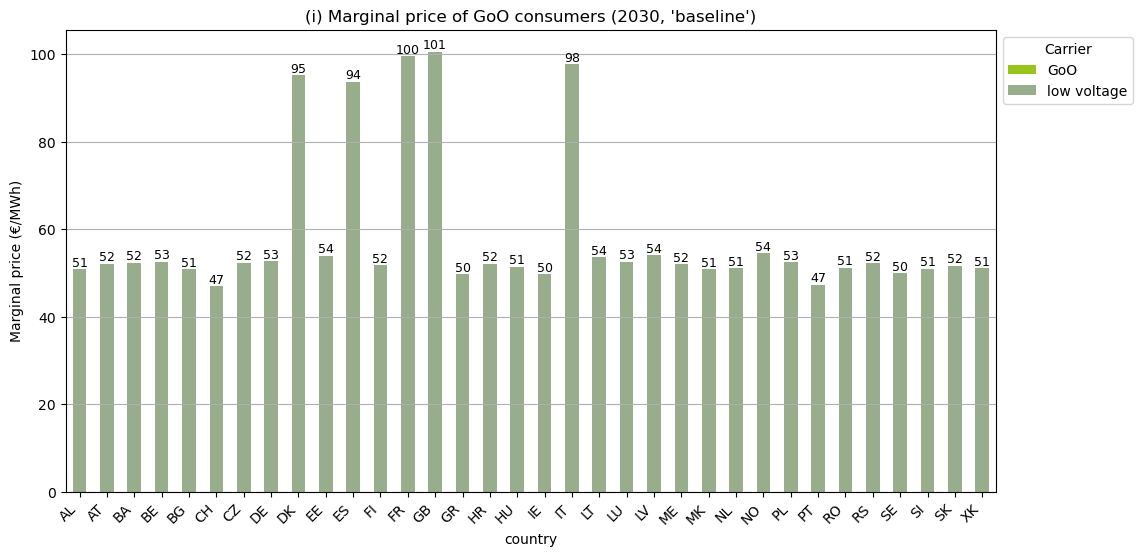

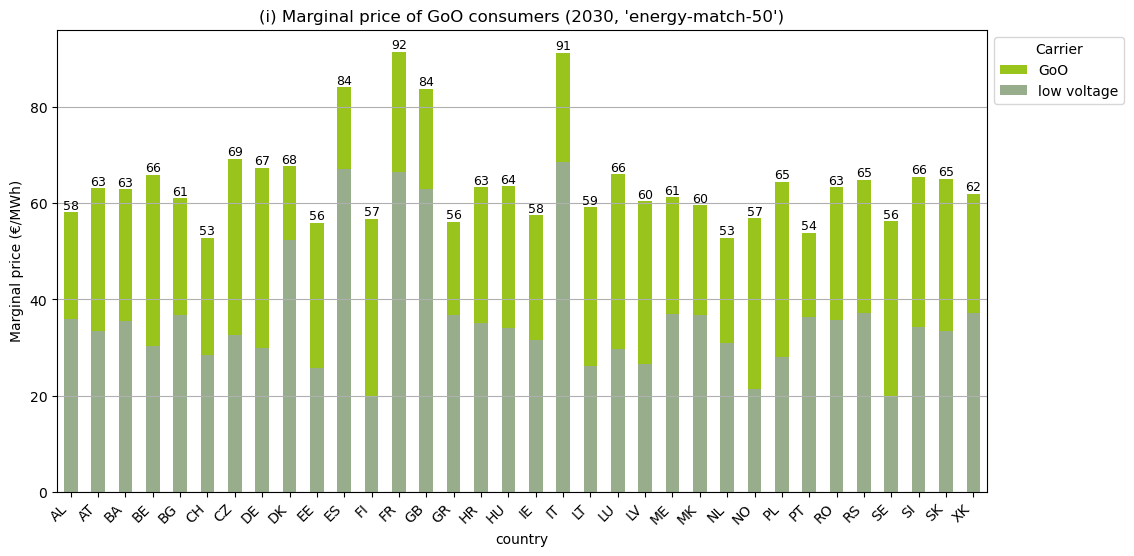

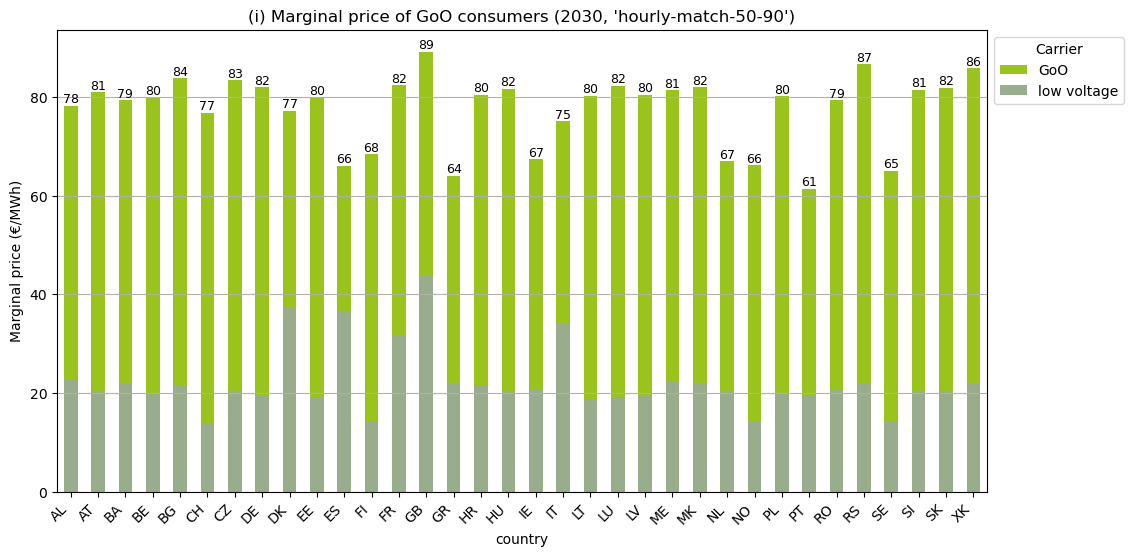

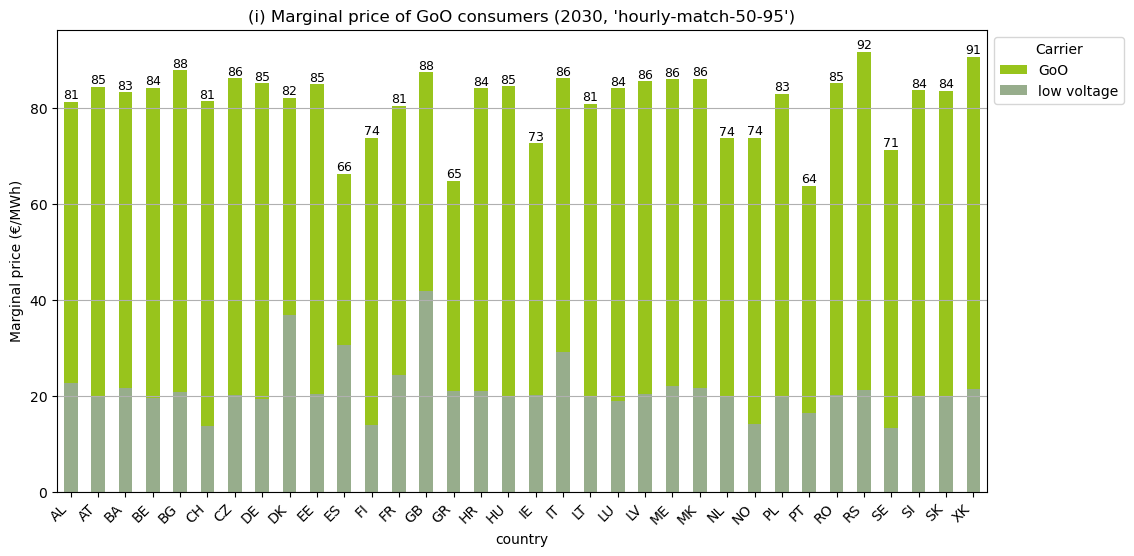

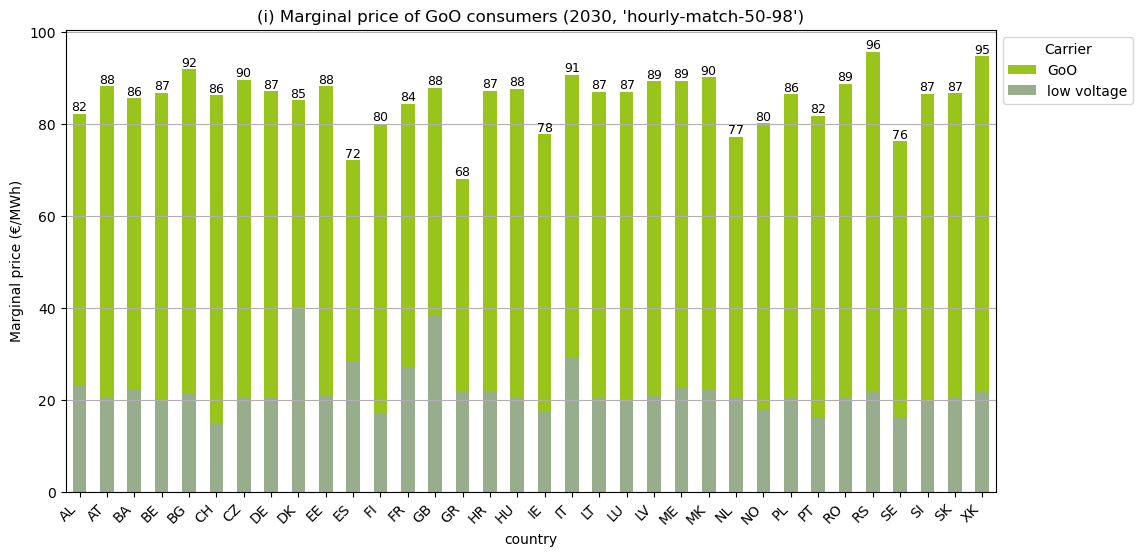

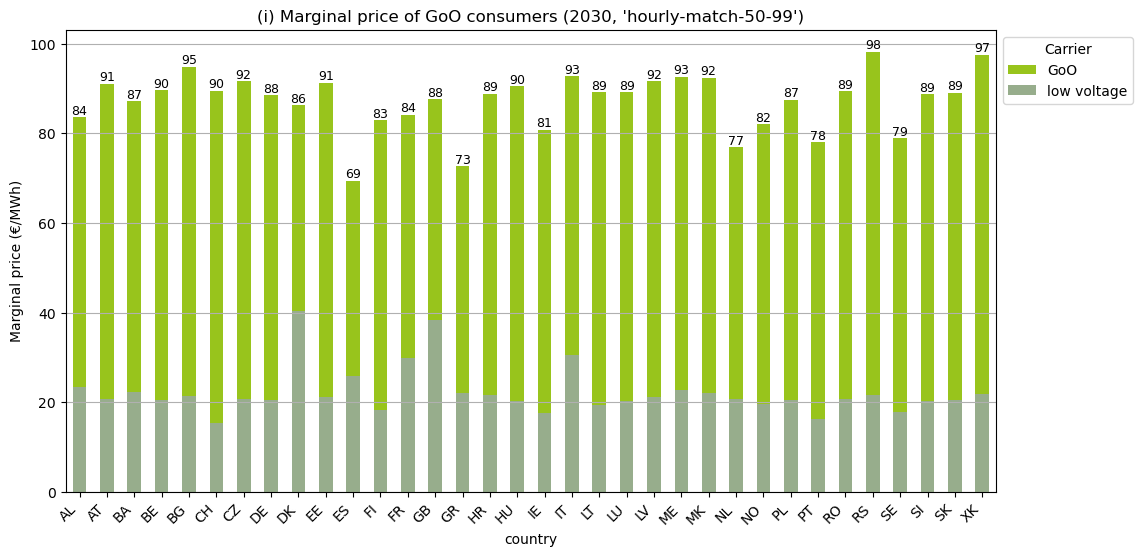

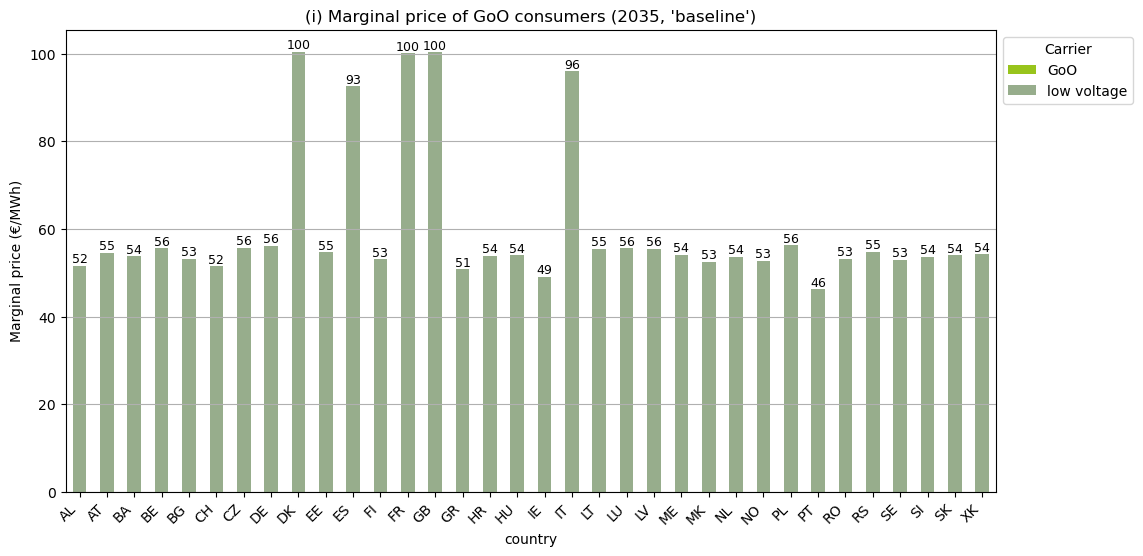

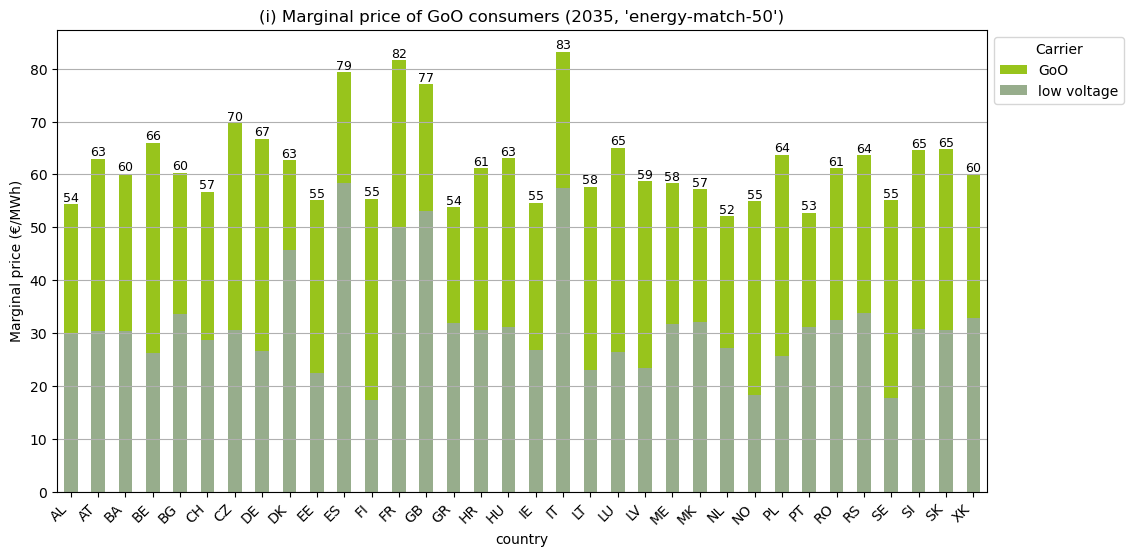

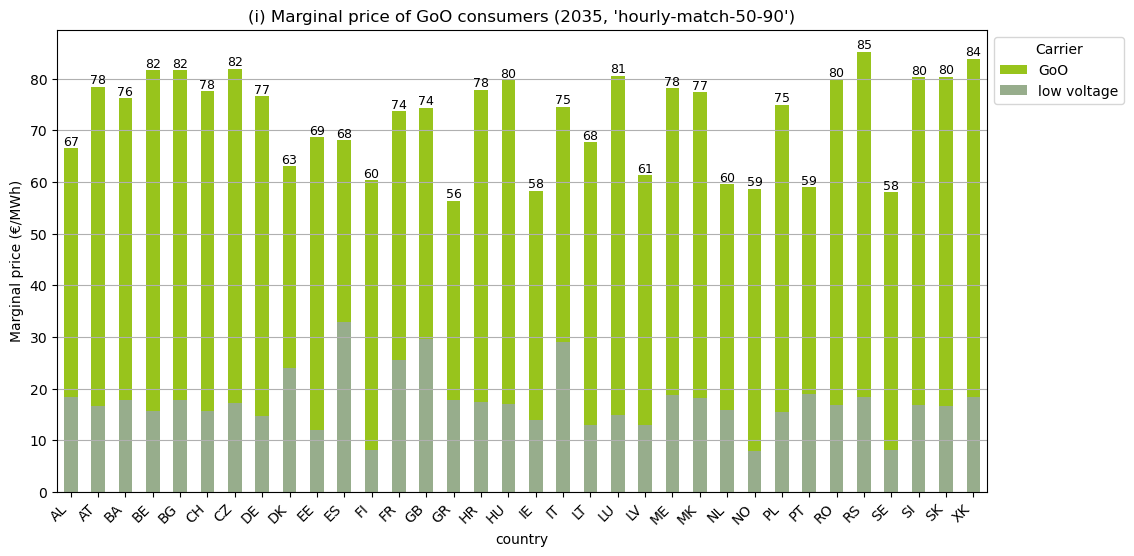

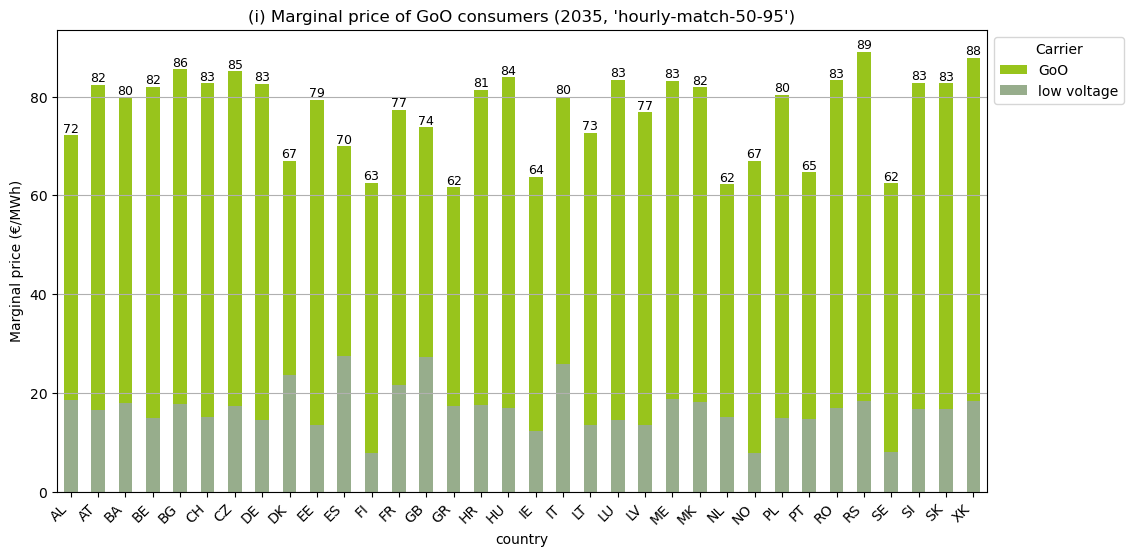

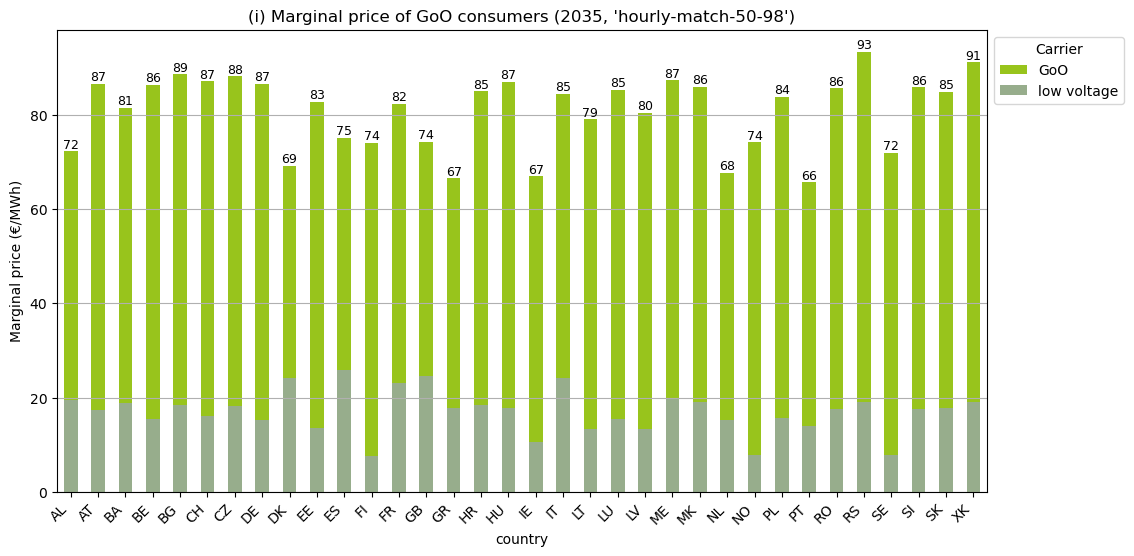

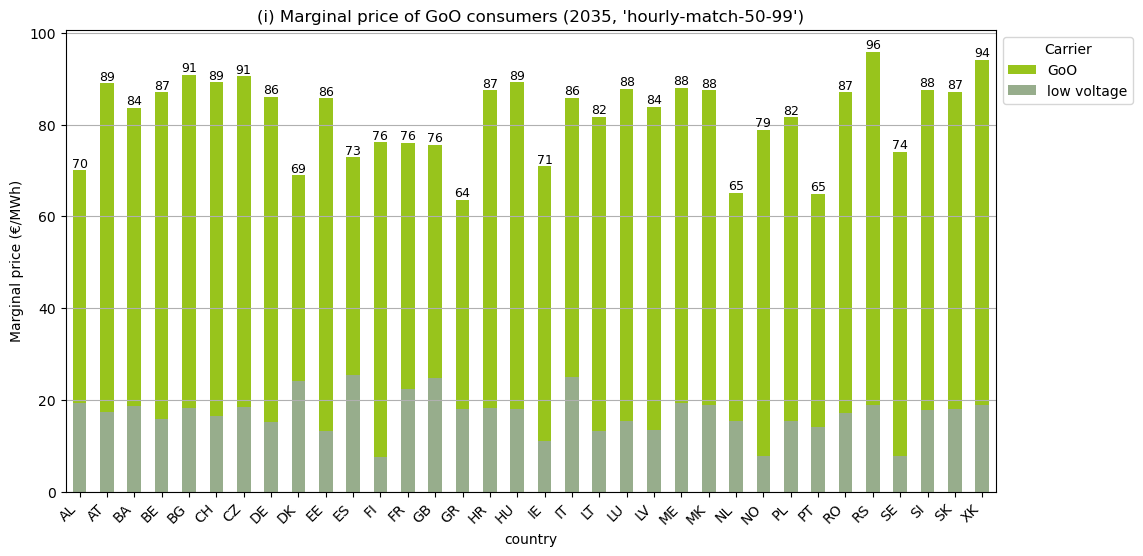

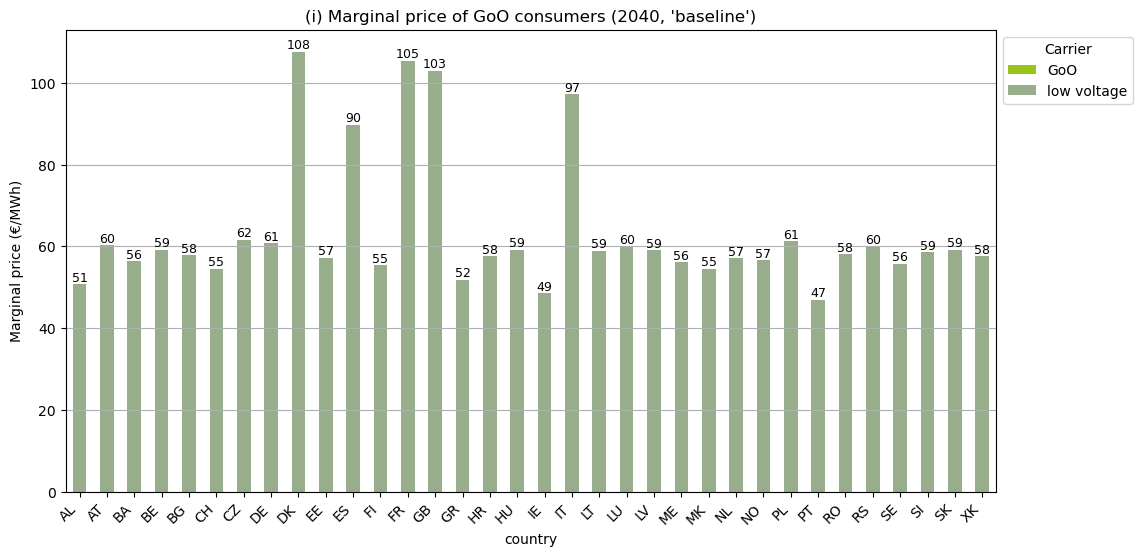

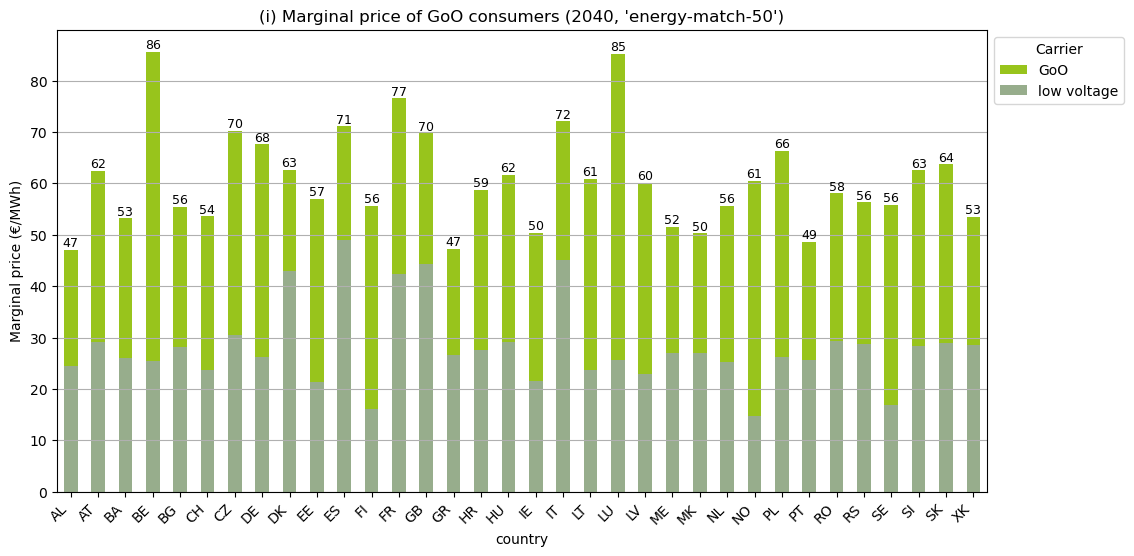

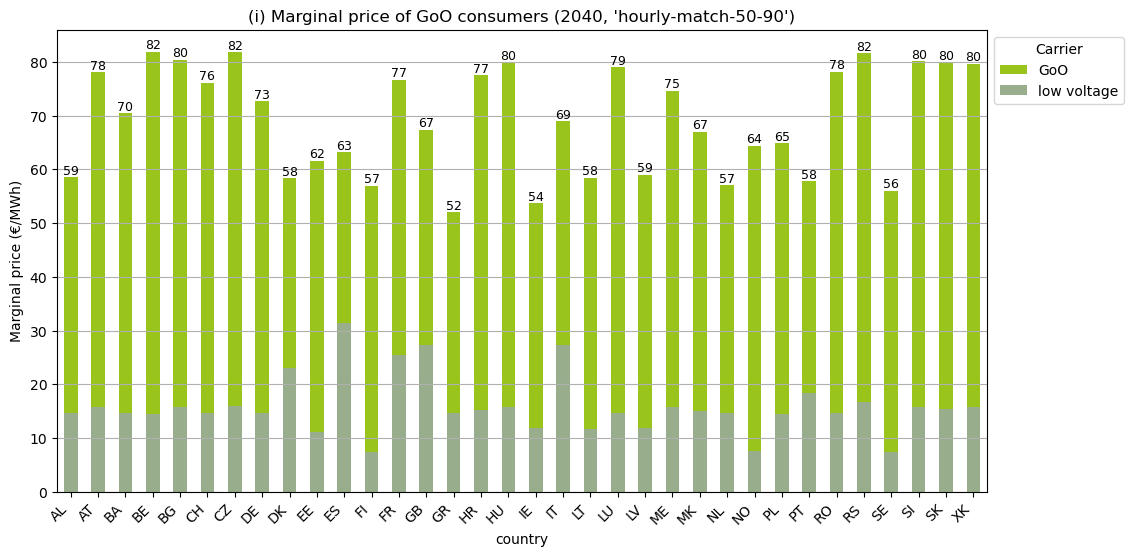

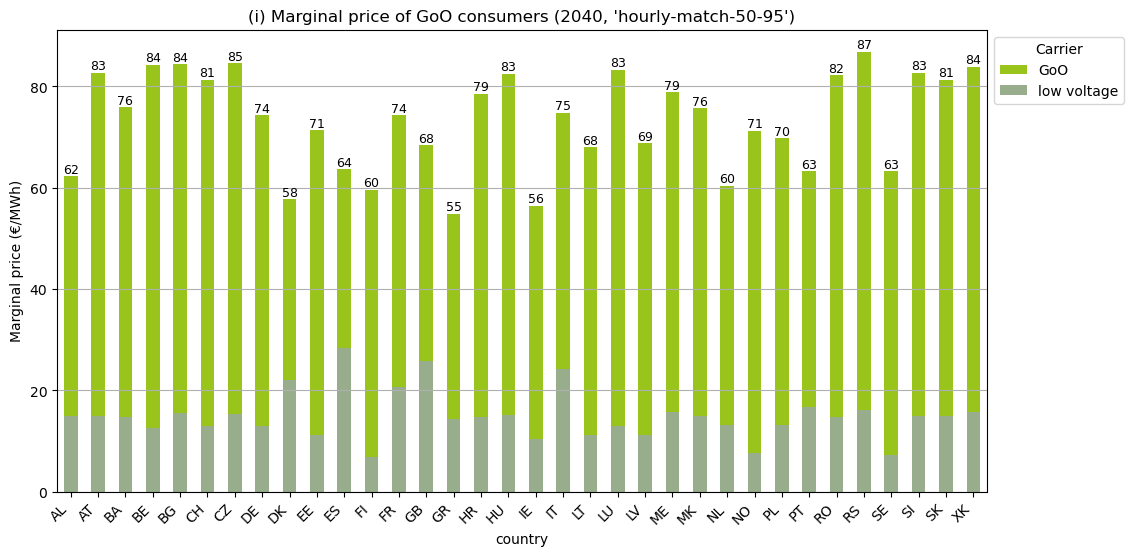

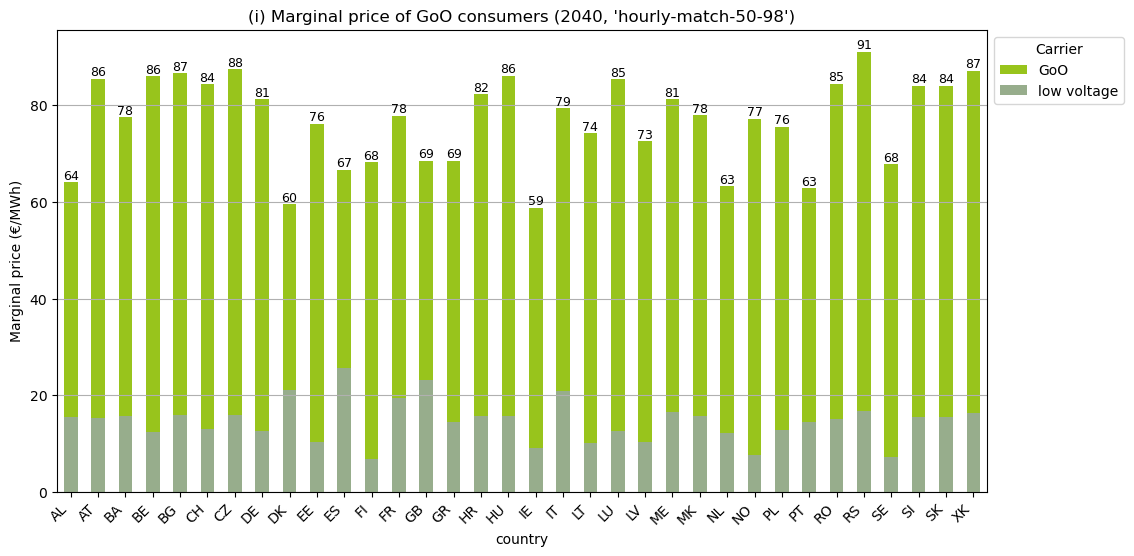

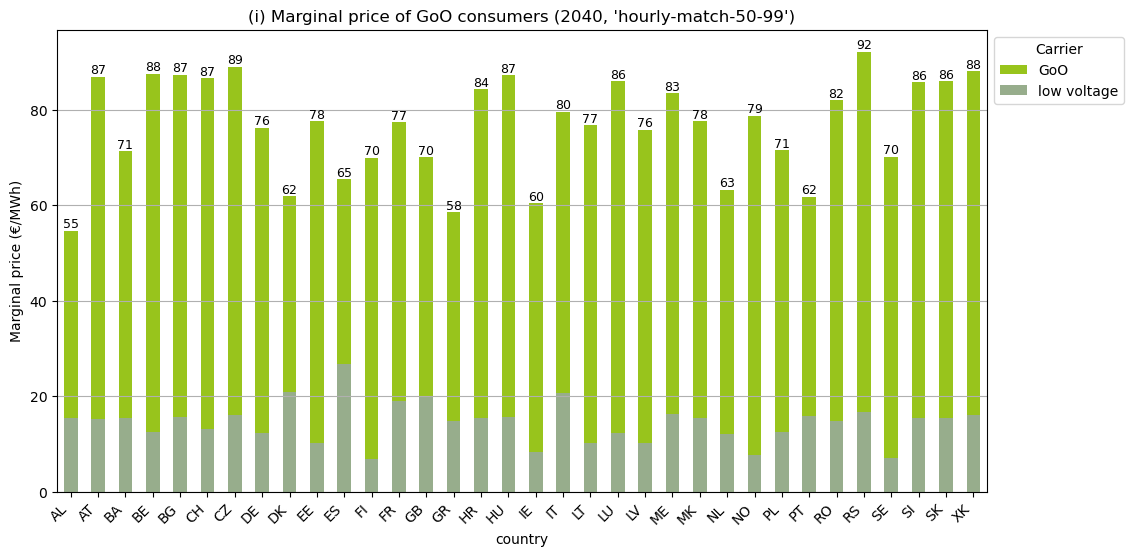

In [33]:
save_fig = True
df, _ = get_stats_prices(df_networks["network"])
df = pd.concat([
    df.filter(like="low voltage", axis=0).copy(),
    df.filter(like="GO Demand", axis=0).copy()
])

df["carrier"] = df.index.map(n.buses.carrier)
df["country"] = df.index.map(n.buses.country)

df = df.groupby(["country","carrier"]).sum()

for i in df.columns:
    fig_path = f"figures/country_comparison/bar_plots"
    print(f"-------------------------------------Analyzing {i}")

    title_fig = f"(i) Marginal price of GoO consumers {i}"
    df_country = df[i]
    df_country = df_country.unstack("country").groupby("carrier").sum()
    
    order = ["low voltage", "GoO"]
    df_country = df_country.reindex(df_country.index.reindex(order)[0])
    
    colors = df_country.index.map(n.carriers.color)
    
    ax = plot_bar(
        df_country, 
        colors, 
        ylabel="Marginal price (€/MWh)", 
        title=title_fig,
        vert_lines=False
    )

    if save_fig:
        os.makedirs(fig_path, exist_ok=True)
        ax.figure.savefig(f"{fig_path}/{title_fig}.png", dpi=300, bbox_inches="tight")

# 3 - GO Market impacts - Energy mix - map plot

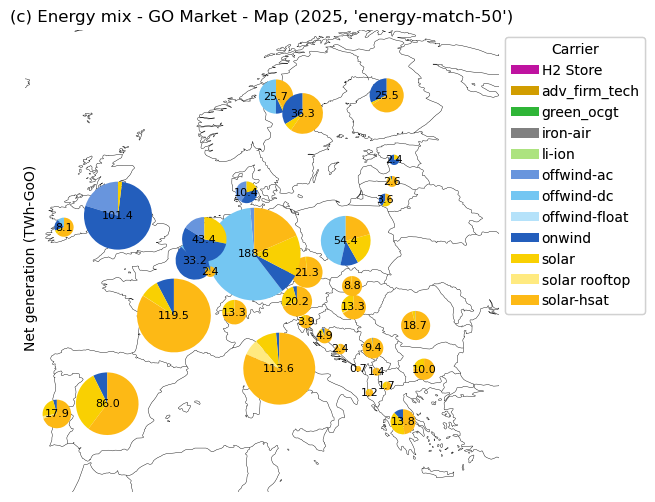

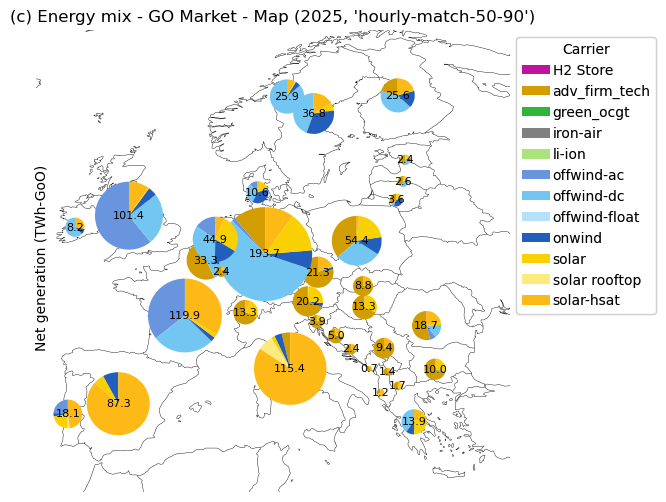

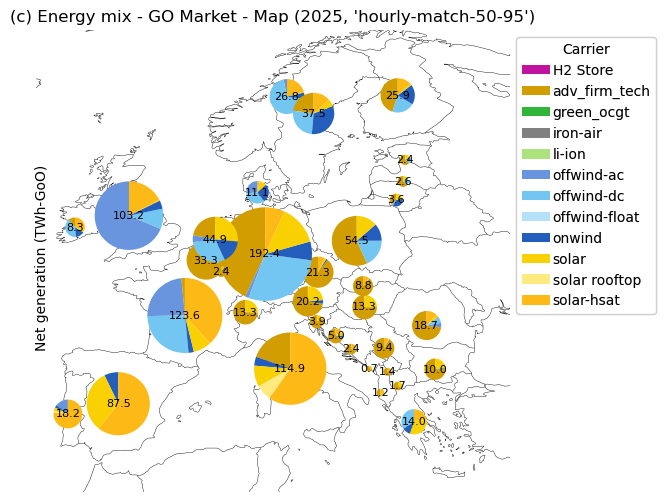

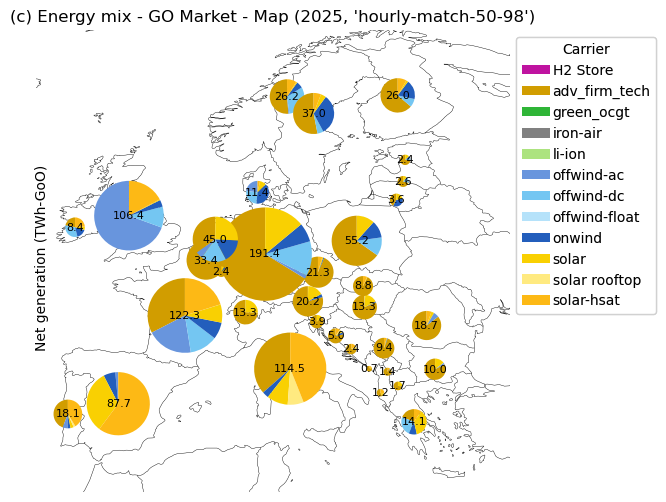

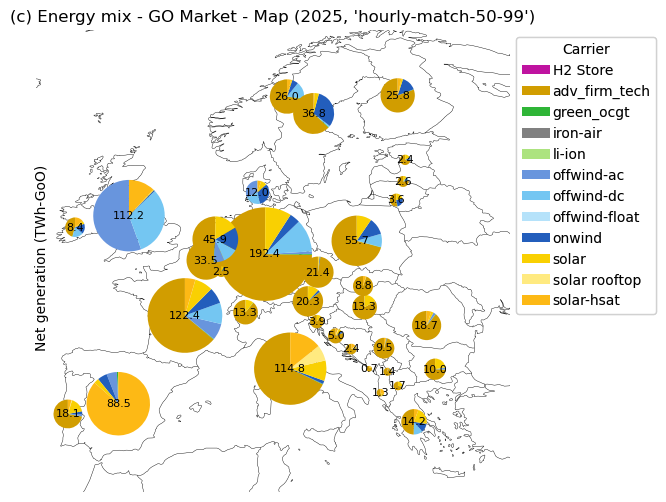

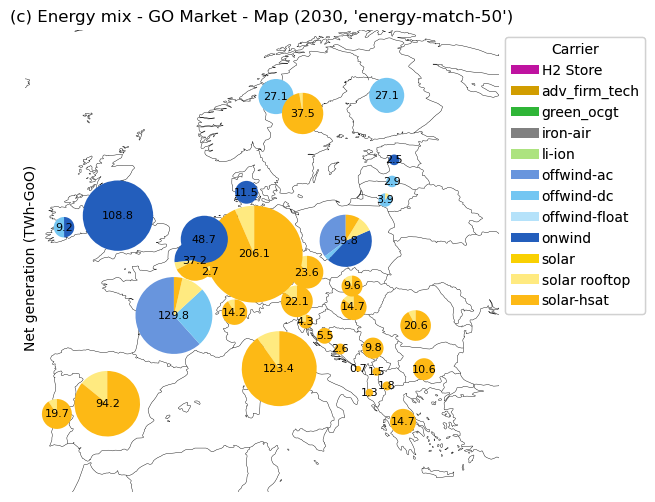

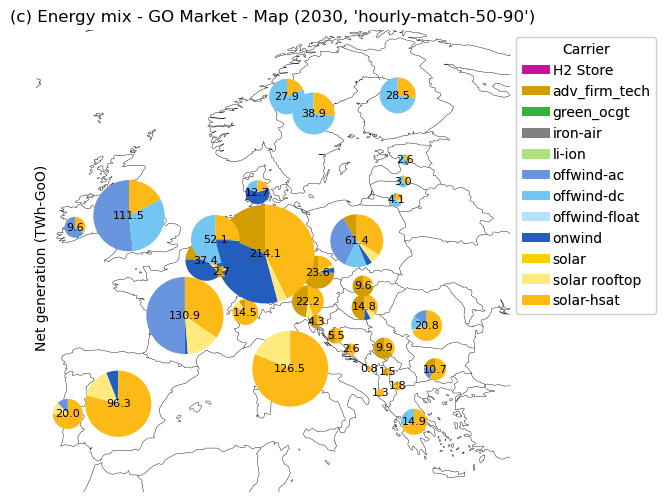

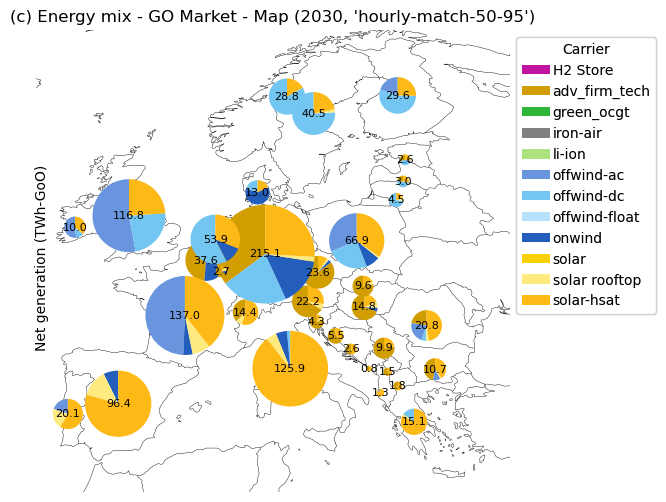

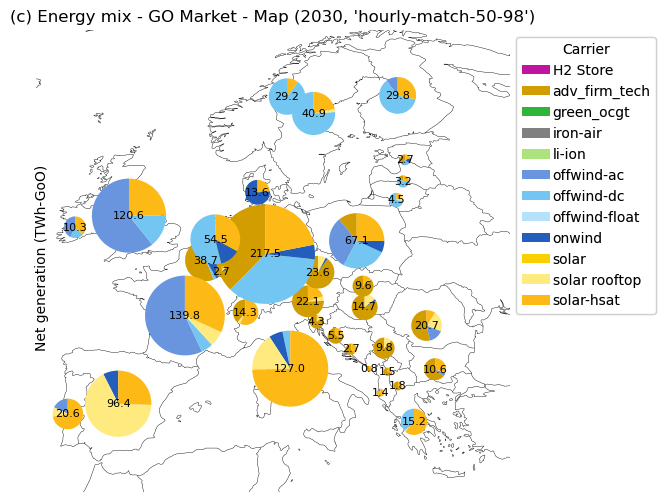

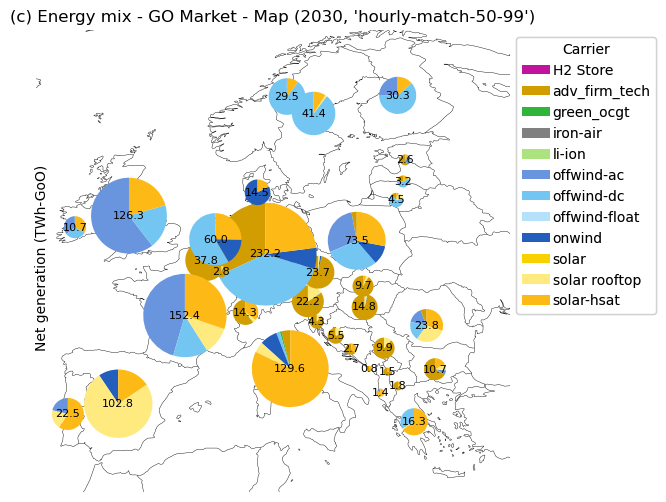

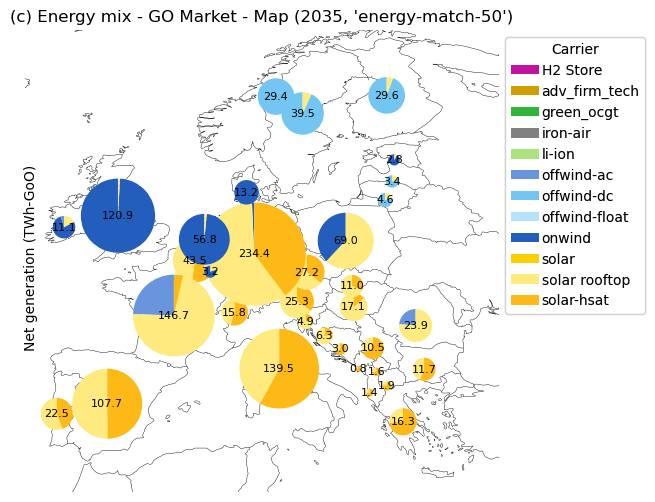

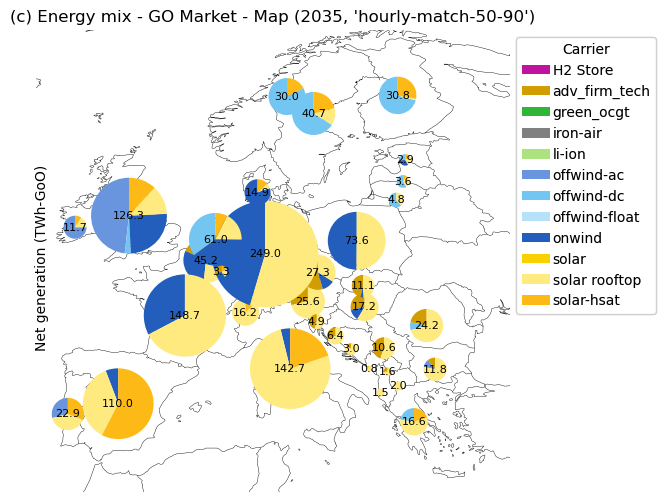

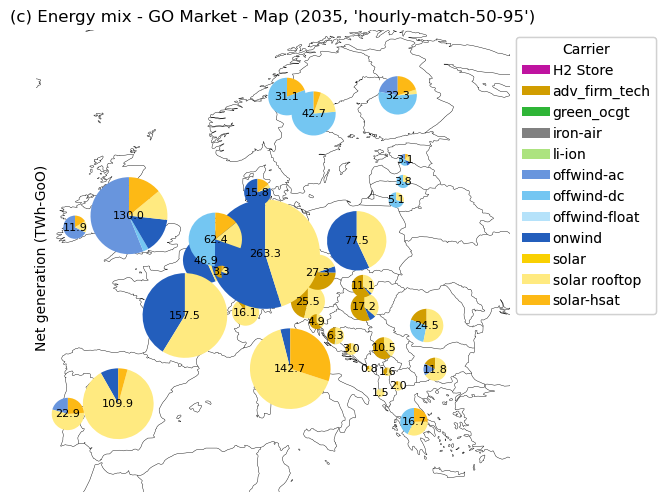

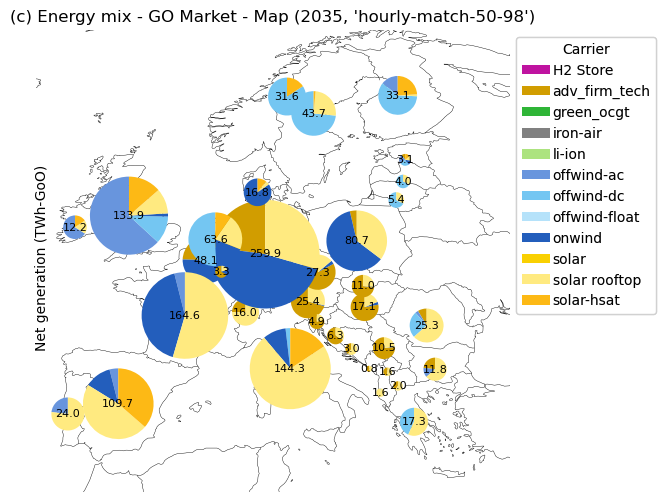

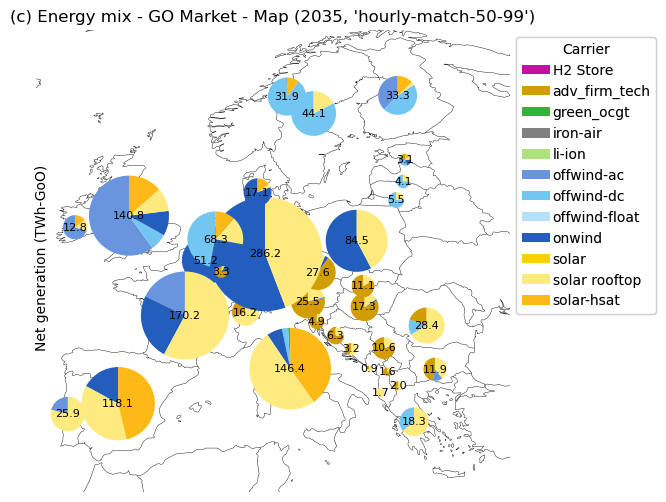

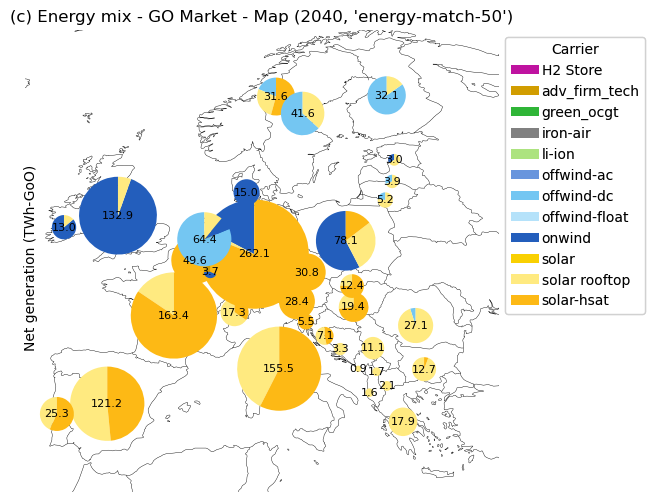

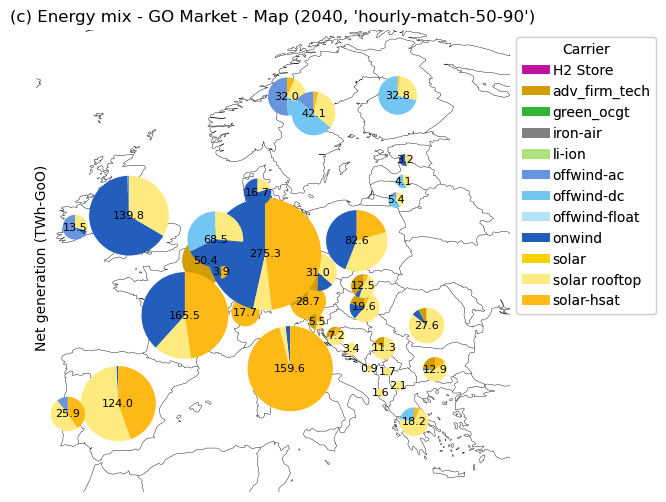

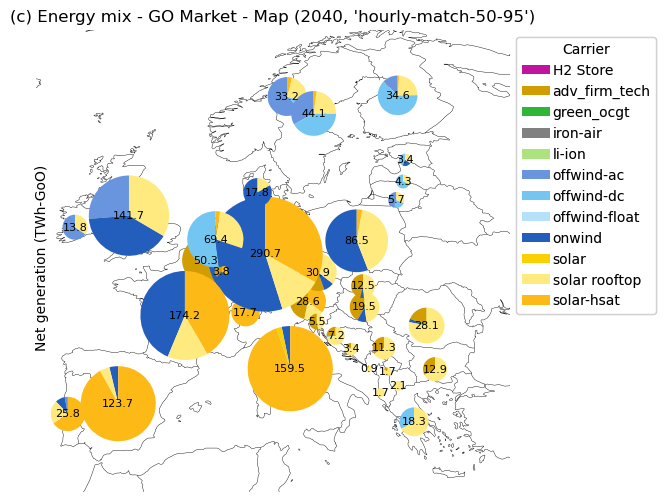

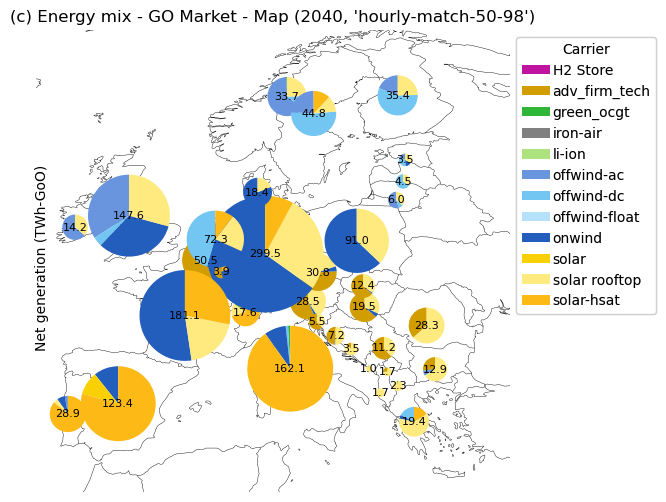

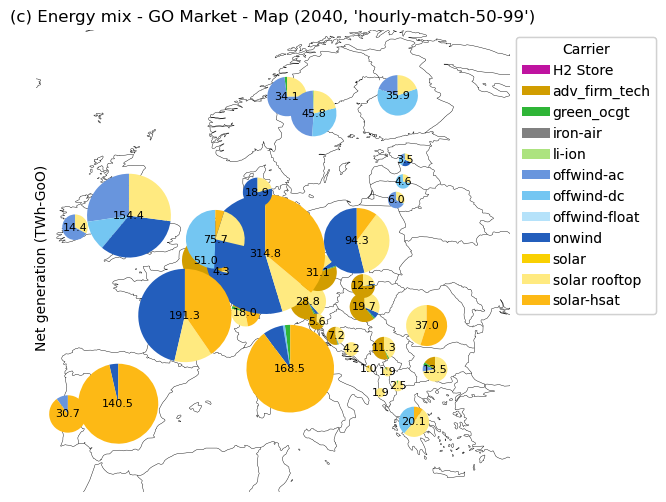

In [ ]:
save_fig = True
fig_path = f"figures/country_comparison/map_plots"

df_GoO = df_networks[df_networks.index.get_level_values("scenario") != "baseline"]
df, colors = get_stats_all(df_GoO["GoO"], "energy_balance", groupby=["bus","carrier"])
df["color"] = colors
df = df[df.index.get_level_values("carrier") != "GoO"].groupby(["bus","carrier"]).apply(sum_except_color)

# Clean 'virtual ' prefix from index names
df = clean_virtual_names(df.copy())

colors = df["color"]
df = df.drop("color", axis=1)
df = df / 1e6

if save_fig:
    os.makedirs(fig_path, exist_ok=True)

plot_map(df, df_GoO["GoO"], colors, unit="Net generation (TWh-GoO)", title="(b) Energy mix - GO Market - Map", save = save_fig, path=fig_path)